In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                             calinski_harabasz_score, classification_report,
                             confusion_matrix, f1_score, accuracy_score, roc_auc_score)
from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                     cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, HistGradientBoostingClassifier,
                              StackingClassifier)
from sklearn.neural_network import MLPClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PALETTE = "tab10"

# Загрузка данных

In [3]:
df_raw = pd.read_csv('CC GENERAL.csv')
print(f"Объектов: {df_raw.shape[0]}, признаков: {df_raw.shape[1]}")
df_raw.head()

Объектов: 8950, признаков: 18


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


# Разведочный анализ (EDA)

## Общее описание

In [5]:
info = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "n_unique": df_raw.nunique(),
    "n_missing": df_raw.isna().sum(),
    "%_missing": (df_raw.isna().mean() * 100).round(2),
})
print(f"Объектов: {len(df_raw)}, признаков: {df_raw.shape[1]}")
print(f"Категориальных признаков: {(df_raw.dtypes == object).sum()}")
print(f"Полных дубликатов: {df_raw.duplicated().sum()}")
info

Объектов: 8950, признаков: 18
Категориальных признаков: 1
Полных дубликатов: 0


,dtype,n_unique,n_missing,%_missing
CUST_ID,object,8950,0,0.00
BALANCE,float64,8871,0,0.00
BALANCE_FREQUENCY,float64,43,0,0.00
PURCHASES,float64,6203,0,0.00
ONEOFF_PURCHASES,float64,4014,0,0.00
INSTALLMENTS_PURCHASES,float64,4452,0,0.00
CASH_ADVANCE,float64,4323,0,0.00
PURCHASES_FREQUENCY,float64,47,0,0.00
ONEOFF_PURCHASES_FREQUENCY,float64,47,0,0.00
PURCHASES_INSTALLMENTS_FREQUENCY,float64,47,0,0.00


In [6]:
df_raw.describe().T[["mean", "std", "min", "25%", "50%", "75%", "max"]].round(2)

,mean,std,min,25%,50%,75%,max
BALANCE,1564.47,2081.53,0.00,128.28,873.39,2054.14,19043.14
BALANCE_FREQUENCY,0.88,0.24,0.00,0.89,1.00,1.00,1.00
PURCHASES,1003.20,2136.63,0.00,39.64,361.28,1110.13,49039.57
ONEOFF_PURCHASES,592.44,1659.89,0.00,0.00,38.00,577.40,40761.25
INSTALLMENTS_PURCHASES,411.07,904.34,0.00,0.00,89.00,468.64,22500.00
CASH_ADVANCE,978.87,2097.16,0.00,0.00,0.00,1113.82,47137.21
PURCHASES_FREQUENCY,0.49,0.40,0.00,0.08,0.50,0.92,1.00
ONEOFF_PURCHASES_FREQUENCY,0.20,0.30,0.00,0.00,0.08,0.30,1.00
PURCHASES_INSTALLMENTS_FREQUENCY,0.36,0.40,0.00,0.00,0.17,0.75,1.00
CASH_ADVANCE_FREQUENCY,0.14,0.20,0.00,0.00,0.00,0.22,1.50


## Распределения признаков

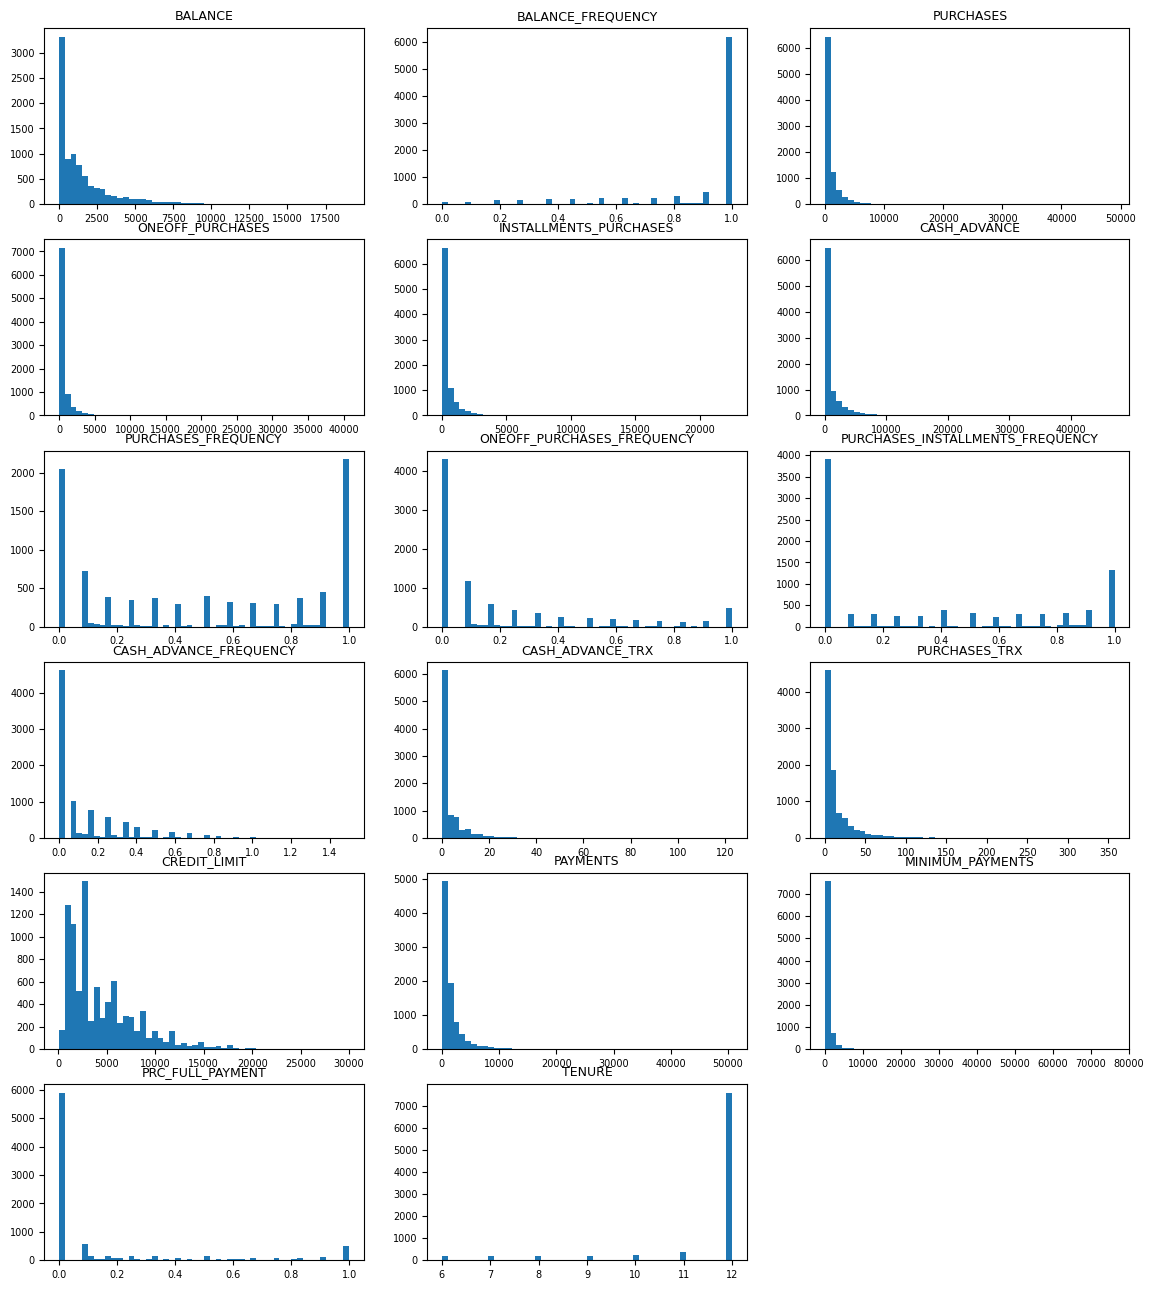

Коэффициент асимметрии:
MINIMUM_PAYMENTS                    13.62
ONEOFF_PURCHASES                    10.05
PURCHASES                            8.14
INSTALLMENTS_PURCHASES               7.30
PAYMENTS                             5.91
CASH_ADVANCE_TRX                     5.72
CASH_ADVANCE                         5.17
PURCHASES_TRX                        4.63
BALANCE                              2.39
PRC_FULL_PAYMENT                     1.94
CASH_ADVANCE_FREQUENCY               1.83
ONEOFF_PURCHASES_FREQUENCY           1.54
CREDIT_LIMIT                         1.52
PURCHASES_INSTALLMENTS_FREQUENCY     0.51
PURCHASES_FREQUENCY                  0.06
BALANCE_FREQUENCY                   -2.02
TENURE                              -2.94


In [11]:
num_cols = df_raw.select_dtypes("number").columns.tolist()
fig, axes = plt.subplots(6, 3, figsize=(14, 16))
for ax, c in zip(axes.ravel(), num_cols):
    ax.hist(df_raw[c].dropna(), bins=50)
    ax.set_title(c, fontsize=9)
    ax.tick_params(labelsize=7)
for ax in axes.ravel()[len(num_cols):]:
    ax.axis("off")
plt.show()

skew = df_raw[num_cols].skew().sort_values(ascending=False)
print("Коэффициент асимметрии:")
print(skew.round(2).to_string())

**Вывод по распределениям**

Денежные признаки имеют тяжёлый правый хвост: у большинства клиентов обороты небольшие, но у единиц
на порядки больше.

Для метрических методов (K-Means, DBSCAN, KNN) это критично:
евклидово расстояние будет определяться почти целиком этими выбросами. Отсюда два
решения: логарифмирование и нормировка на кредитный лимит
## Выбросы

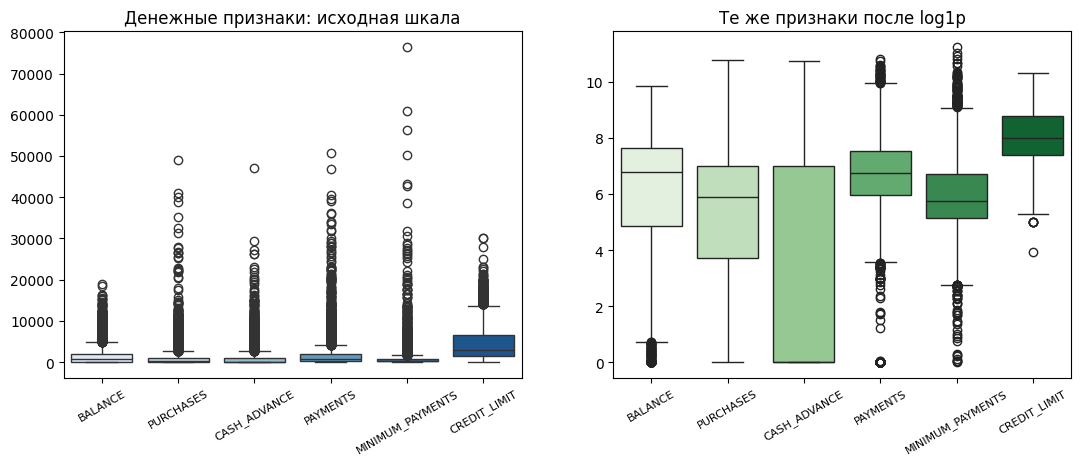

Доля объектов выше 99-го перцентиля:
BALANCE             1.01
PURCHASES           1.01
CASH_ADVANCE        1.01
PAYMENTS            1.01
MINIMUM_PAYMENTS    0.97
CREDIT_LIMIT        0.87


In [12]:
money = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "PAYMENTS", "MINIMUM_PAYMENTS", "CREDIT_LIMIT"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.boxplot(data=df_raw[money], ax=axes[0], palette="Blues")
axes[0].set_title("Денежные признаки: исходная шкала")
axes[0].tick_params(axis="x", rotation=30, labelsize=8)
sns.boxplot(data=np.log1p(df_raw[money]), ax=axes[1], palette="Greens")
axes[1].set_title("Те же признаки после log1p")
axes[1].tick_params(axis="x", rotation=30, labelsize=8)
plt.show()

q99 = df_raw[money].quantile(0.99)
share = pd.Series({c: (df_raw[c] > q99[c]).mean() for c in money})
print("Доля объектов выше 99-го перцентиля:")
print((share * 100).round(2).to_string())

**Решение по выбросам:** не удаляем. Клиент с оборотом в 50 000 - это не ошибка ввода,
а реальный VIP-сегмент, ради которого сегментация во многом и делается.

Вместо удаления
применяем два приёма: `log1p` (сжимает хвост, не теряя порядок) и винсоризацию на уровне
99-го перцентиля для производных отношений, где деление на малое число даёт бессмысленные
значения в тысячи раз выше типичных

## Корреляции

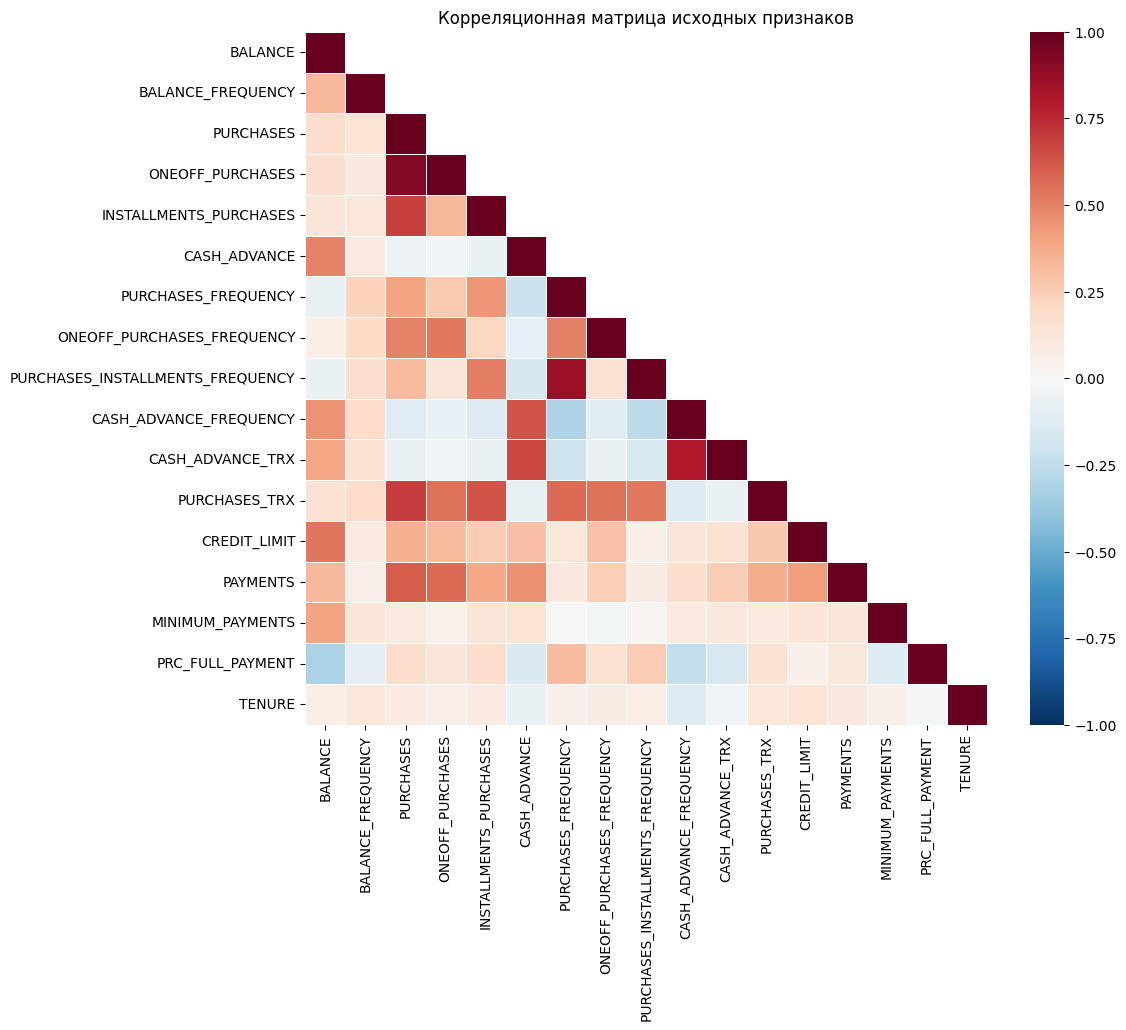

In [15]:
corr = df_raw[num_cols].corr()
fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmax=1, vmin=-1, linewidths=.5, ax=ax)
ax.set_title("Корреляционная матрица исходных признаков")
plt.show()

**Вывод по корреляциям**

Видны блоки сильно связанных признаков:
- `PURCHASES` с `ONEOFF_PURCHASES`/`INSTALLMENTS_PURCHASES` (первый это сумма двух вторых)
- `CASH_ADVANCE` с `CASH_ADVANCE_TRX` и `CASH_ADVANCE_FREQUENCY`

Это прямая мультиколлинеарность:
в пространстве с такими признаками кластеризация неявно даёт двойной вес «покупательскому»
и «наличному» измерениям

Решение: PCA перед кластеризацией

# Предобработка

In [17]:
df = df_raw.copy()

print("Пропусков до обработки:", df.isna().sum().sum())
if df["MINIMUM_PAYMENTS"].isna().any():
    bins = pd.qcut(df["BALANCE"], 10, duplicates="drop")
    df["MINIMUM_PAYMENTS"] = (df.groupby(bins, observed=True)["MINIMUM_PAYMENTS"]
                                .transform(lambda s: s.fillna(s.median())))
    df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

df = df.drop_duplicates(subset=["CUST_ID"]).reset_index(drop=True)
num = df.select_dtypes("number").columns
df[num] = df[num].clip(lower=0)

print("Пропусков после обработки:", df.isna().sum().sum())
print("Размер после очистки:", df.shape)

Пропусков до обработки: 314
Пропусков после обработки: 0
Размер после очистки: (8950, 18)


# Feature engineering

Девять новых признаков. Общая логика: сырые суммы несопоставимы между клиентами
с разным кредитным лимитом и разным сроком обслуживания, поэтому строим относительные
величины

| Признак | Формула | Зачем нужен |
|---|---|---|
| `MONTHLY_AVG_PURCHASE` | `PURCHASES / TENURE` | Приводит обороты к одному месяцу: клиент с 6 и 12 месяцами обслуживания становится сравним |
| `MONTHLY_CASH_ADVANCE` | `CASH_ADVANCE / TENURE` | То же для снятия наличных |
| `LIMIT_USAGE` | `BALANCE / CREDIT_LIMIT` | Утилизация лимита - ключевая риск-метрика в кредитном скоринге; высокая утилизация коррелирует с дефолтом |
| `PURCHASE_TO_LIMIT` | `PURCHASES / CREDIT_LIMIT` | Отделяет активного клиента с малым лимитом от пассивного с большим |
| `PAYMENT_TO_MINPAY` | `PAYMENTS / MINIMUM_PAYMENTS` | Во сколько раз клиент платит больше минимального платежа: около 1 - револьвер, много больше 1 - транзактор |
| `AVG_PURCHASE_TRX` | `PURCHASES / PURCHASES_TRX` | Средний чек: разделяет «много мелких покупок» и «редкие крупные» при равном обороте |
| `CASH_SHARE` | `CASH_ADVANCE / (CASH_ADVANCE + PURCHASES)` | Доля наличных в обороте - прямой маркер самого дорогого и рискованного способа пользования картой |
| `PURCHASE_TYPE_BOTH` | `1[oneoff>0 и instal>0]` | Использует ли клиент оба типа покупок - признак глубины продукта |
| `PURCHASE_TYPE_NONE` | `1[oneoff=0 и instal=0]` | Явный маркер «спящего» клиента, которого иначе трудно отделить от малоактивного |

In [18]:
def engineer(d):
    d = d.copy()
    eps = 1e-6
    limit = d["CREDIT_LIMIT"].replace(0, np.nan)
    ten = d["TENURE"].clip(lower=1)

    d["MONTHLY_AVG_PURCHASE"] = d["PURCHASES"] / ten
    d["MONTHLY_CASH_ADVANCE"] = d["CASH_ADVANCE"] / ten
    d["LIMIT_USAGE"] = (d["BALANCE"] / limit).fillna(0)
    d["PURCHASE_TO_LIMIT"] = (d["PURCHASES"] / limit).fillna(0)
    d["PAYMENT_TO_MINPAY"] = d["PAYMENTS"] / (d["MINIMUM_PAYMENTS"] + eps)
    d["AVG_PURCHASE_TRX"] = d["PURCHASES"] / (d["PURCHASES_TRX"] + eps)
    d["CASH_SHARE"] = d["CASH_ADVANCE"] / (d["CASH_ADVANCE"] + d["PURCHASES"] + eps)
    oneoff, instal = d["ONEOFF_PURCHASES"] > 0, d["INSTALLMENTS_PURCHASES"] > 0
    d["PURCHASE_TYPE_BOTH"] = (oneoff & instal).astype(int)
    d["PURCHASE_TYPE_NONE"] = (~oneoff & ~instal).astype(int)

    for c in ["PAYMENT_TO_MINPAY", "AVG_PURCHASE_TRX", "LIMIT_USAGE", "PURCHASE_TO_LIMIT"]:
        d[c] = d[c].clip(upper=d[c].quantile(0.99))
    return d

feats = engineer(df)
ENGINEERED = ["MONTHLY_AVG_PURCHASE", "MONTHLY_CASH_ADVANCE", "LIMIT_USAGE",
              "PURCHASE_TO_LIMIT", "PAYMENT_TO_MINPAY", "AVG_PURCHASE_TRX",
              "CASH_SHARE", "PURCHASE_TYPE_BOTH", "PURCHASE_TYPE_NONE"]
feats[ENGINEERED].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
MONTHLY_AVG_PURCHASE,8950.0,86.175,180.509,0.0,3.399,31.937,97.228,4086.631
MONTHLY_CASH_ADVANCE,8950.0,88.978,193.136,0.0,0.000,0.000,99.085,3928.101
LIMIT_USAGE,8950.0,0.386,0.350,0.0,0.041,0.303,0.718,1.057
PURCHASE_TO_LIMIT,8950.0,0.252,0.360,0.0,0.011,0.117,0.338,1.957
PAYMENT_TO_MINPAY,8950.0,5.296,8.291,0.0,0.918,2.059,6.117,50.905
AVG_PURCHASE_TRX,8950.0,69.294,110.706,0.0,12.000,41.428,78.762,786.633
CASH_SHARE,8950.0,0.380,0.443,0.0,0.000,0.000,0.954,1.000
PURCHASE_TYPE_BOTH,8950.0,0.310,0.462,0.0,0.000,0.000,1.000,1.000
PURCHASE_TYPE_NONE,8950.0,0.228,0.420,0.0,0.000,0.000,0.000,1.000


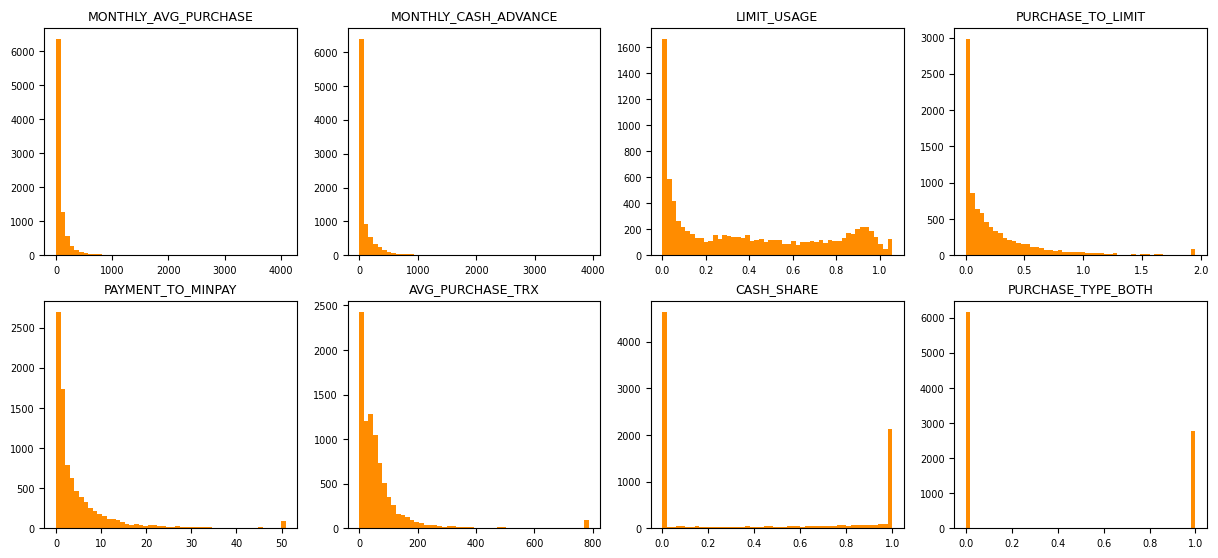

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5))
for ax, c in zip(axes.ravel(), ENGINEERED[:8]):
    ax.hist(feats[c], bins=50, color="darkorange", edgecolor="none")
    ax.set_title(c, fontsize=9); ax.tick_params(labelsize=7)
plt.show()

# Кластеризация

## Подготовка пространства признаков

Порядок операций и обоснование:

1. **`log1p`** для скошенных денежных признаков
2. **`StandardScaler`**
  
    K-Means и DBSCAN опираются на расстояния, поэтому признаки должны быть в одном масштабе.
3. **PCA с сохранением 90 % дисперсии**
    
    снимает мультиколлинеарность и снижает проклятие размерности для DBSCAN, чувствительного к числу измерений

In [21]:
SKEWED = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
          "CASH_ADVANCE", "CASH_ADVANCE_TRX", "PURCHASES_TRX", "CREDIT_LIMIT",
          "PAYMENTS", "MINIMUM_PAYMENTS"]
BOUNDED = ["BALANCE_FREQUENCY", "PURCHASES_FREQUENCY", "ONEOFF_PURCHASES_FREQUENCY",
           "PURCHASES_INSTALLMENTS_FREQUENCY", "CASH_ADVANCE_FREQUENCY",
           "PRC_FULL_PAYMENT", "TENURE"]
LOG_FEATURES = SKEWED + ["MONTHLY_AVG_PURCHASE", "MONTHLY_CASH_ADVANCE",
                         "PAYMENT_TO_MINPAY", "AVG_PURCHASE_TRX"]
PLAIN_FEATURES = BOUNDED + ["LIMIT_USAGE", "PURCHASE_TO_LIMIT", "CASH_SHARE",
                            "PURCHASE_TYPE_BOTH", "PURCHASE_TYPE_NONE"]
ALL_FEATURES = LOG_FEATURES + PLAIN_FEATURES

def build_preprocessor(use_pca=True, variance=0.90):
    log_tf = Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                       ("scale", StandardScaler())])
    ct = ColumnTransformer([("log", log_tf, LOG_FEATURES),
                            ("plain", StandardScaler(), PLAIN_FEATURES)])
    steps = [("prep", ct)]
    if use_pca:
        steps.append(("pca", PCA(n_components=variance, random_state=RANDOM_STATE)))
    return Pipeline(steps)

X_raw = feats[ALL_FEATURES]
pre = build_preprocessor()
X = pre.fit_transform(X_raw)
pca = pre.named_steps["pca"]
print(f"Признаков до PCA: {X_raw.shape[1]}, компонент после PCA: {X.shape[1]}")
print("Объяснённая дисперсия по компонентам:",
      np.round(pca.explained_variance_ratio_, 3))
print("Суммарно:", round(pca.explained_variance_ratio_.sum(), 3))

Признаков до PCA: 26, компонент после PCA: 9
Объяснённая дисперсия по компонентам: [0.385 0.184 0.083 0.065 0.054 0.045 0.035 0.031 0.025]
Суммарно: 0.908


## K-Means

Ниже перебираем k от 2 до 10 и смотрим на три критерия:
- nertia
- silhouette
- Davies-Bouldin

Глобальный максимум silhouette на этих данных
достигается при k=2. Формально это лучшее геометрическое разбиение, но содержательно
оно бесполезно: два кластера делят базу на «тех, кто платит картой» и «тех, кто снимает
наличные» - это и так известно и не даёт материала для профилирования и таргетирования.
Кроме того, при k=2 задача классификации вырождается в бинарную, а сегментация
клиентской базы на две группы не даёт продукту работать с разными сценариями.

Поэтому вводим **явное ограничение снизу: k >= 3** и выбираем лучшее k внутри этого
диапазона. Это осознанное решение в пользу интерпретируемости, а не подгонка метрики,
и оно фиксируется в отчёте

In [24]:
def elbow_k(ks, inertias):
    """Метод локтя численно: точка максимального удаления кривой от хорды"""
    k = np.asarray(ks, float); y = np.asarray(inertias, float)
    kn = (k - k.min()) / (np.ptp(k) + 1e-12); yn = (y - y.min()) / (np.ptp(y) + 1e-12)
    p1, p2 = np.array([kn[0], yn[0]]), np.array([kn[-1], yn[-1]])
    line = (p2 - p1) / np.linalg.norm(p2 - p1)
    pts = np.column_stack([kn, yn]) - p1
    return int(k[np.linalg.norm(pts - np.outer(pts @ line, line), axis=1).argmax()])

rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(X, km.labels_),
                 "davies_bouldin": davies_bouldin_score(X, km.labels_),
                 "calinski_harabasz": calinski_harabasz_score(X, km.labels_)})
km_search = pd.DataFrame(rows)

MIN_K = 3 # ограничение

K_ELBOW = elbow_k(km_search.k, km_search.inertia)
K_SIL_ALL = int(km_search.loc[km_search.silhouette.idxmax(), "k"])
sub = km_search[km_search.k >= MIN_K]
K_SIL = int(sub.loc[sub.silhouette.idxmax(), "k"])
K = K_ELBOW if abs(K_ELBOW - K_SIL) <= 1 else K_SIL

print(f"Локоть: k={K_ELBOW}")
print(f"Максимум silhouette по всем k: k={K_SIL_ALL} "
      f"(silhouette={km_search.silhouette.max():.4f})")
print(f"Максимум silhouette при k >= {MIN_K}: k={K_SIL} "
      f"(silhouette={sub.silhouette.max():.4f})")
print(f"ВЫБРАНО: k={K}")
km_search.round(3)

Локоть: k=4
Максимум silhouette по всем k: k=2 (silhouette=0.3229)
Максимум silhouette при k >= 3: k=4 (silhouette=0.2717)
ВЫБРАНО: k=4


,k,inertia,silhouette,davies_bouldin,calinski_harabasz
0,2,141090.564,0.323,1.204,4445.170
1,3,116595.075,0.262,1.546,3629.070
2,4,98469.483,0.272,1.425,3413.307
3,5,89653.823,0.261,1.490,3031.278
4,6,83054.441,0.260,1.423,2759.555
5,7,77904.706,0.249,1.476,2549.892
6,8,73834.312,0.233,1.528,2376.279
7,9,70093.986,0.231,1.508,2249.590
8,10,66709.102,0.227,1.536,2151.273


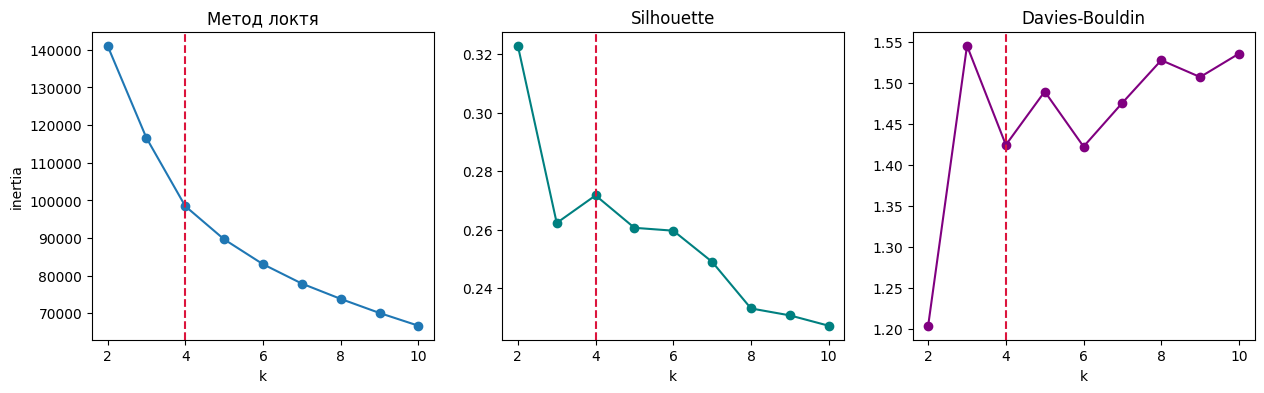

Размеры кластеров K-Means: [1798 2963 2110 2079]


In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(km_search.k, km_search.inertia, "o-"); axes[0].axvline(K, ls="--", c="crimson")
axes[0].set(title="Метод локтя", xlabel="k", ylabel="inertia")
axes[1].plot(km_search.k, km_search.silhouette, "o-", c="teal"); axes[1].axvline(K, ls="--", c="crimson")
axes[1].set(title="Silhouette", xlabel="k")
axes[2].plot(km_search.k, km_search.davies_bouldin, "o-", c="purple"); axes[2].axvline(K, ls="--", c="crimson")
axes[2].set(title="Davies-Bouldin", xlabel="k")
plt.show()

kmeans = KMeans(n_clusters=K, n_init=20, random_state=RANDOM_STATE).fit(X)
km_labels = kmeans.labels_
print("Размеры кластеров K-Means:", np.bincount(km_labels))

## DBSCAN: подбор eps и min_samples

`eps` выбирается по «колену» графика расстояний до k-го соседа. Дальше - сетка по `eps × min_samples` с отбором по silhouette
при доле шума не выше 25 %.

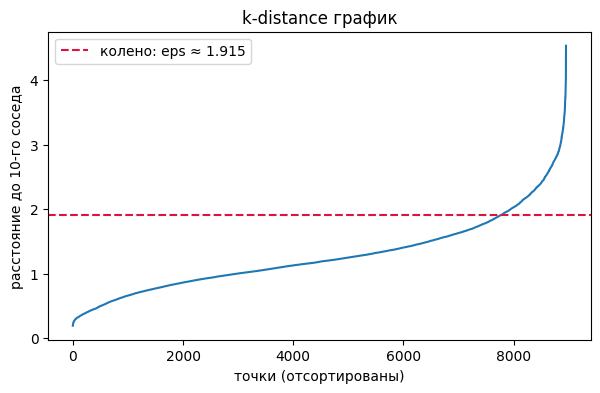

In [27]:
MIN_SAMPLES = 10
nn = NearestNeighbors(n_neighbors=MIN_SAMPLES).fit(X)
dists = np.sort(nn.kneighbors(X)[0][:, -1])

x = np.linspace(0, 1, len(dists))
yv = (dists - dists.min()) / (np.ptp(dists) + 1e-12)
line = np.array([1.0, yv[-1] - yv[0]]); line /= np.linalg.norm(line)
pts = np.column_stack([x, yv - yv[0]])
EPS0 = float(dists[np.linalg.norm(pts - np.outer(pts @ line, line), axis=1).argmax()])

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(dists); ax.axhline(EPS0, ls="--", c="crimson", label=f"колено: eps ≈ {EPS0:.3f}")
ax.set(title="k-distance график", xlabel="точки (отсортированы)",
       ylabel=f"расстояние до {MIN_SAMPLES}-го соседа")
ax.legend(); plt.show()

In [28]:
rows = []
for eps in np.round(EPS0 * np.array([0.6, 0.8, 1.0, 1.3, 1.7]), 3):
    for ms in (5, 10, 20):
        lab = DBSCAN(eps=eps, min_samples=ms, n_jobs=-1).fit_predict(X)
        mask = lab != -1
        nc = len(set(lab[mask]))
        sil = silhouette_score(X[mask], lab[mask]) if nc >= 2 and mask.sum() > nc else np.nan
        rows.append({"eps": eps, "min_samples": ms, "n_clusters": nc,
                     "noise_ratio": round(1 - mask.mean(), 4), "silhouette_core": sil})
db_search = pd.DataFrame(rows)
ok = db_search[(db_search.noise_ratio <= 0.25) & (db_search.n_clusters >= 2)
               & db_search.silhouette_core.notna()]
if len(ok):
    best_db = ok.sort_values("silhouette_core", ascending=False).iloc[0]
    db_labels = DBSCAN(eps=best_db.eps, min_samples=int(best_db.min_samples),
                       n_jobs=-1).fit_predict(X)
    print("Лучшая конфигурация DBSCAN:", dict(best_db))
else:
    db_labels = np.full(len(X), -1)
    print("Подходящей конфигурации DBSCAN не найдено")
db_search.sort_values("silhouette_core", ascending=False).round(3).head(10)

Лучшая конфигурация DBSCAN: {'eps': np.float64(1.532), 'min_samples': np.float64(20.0), 'n_clusters': np.float64(4.0), 'noise_ratio': np.float64(0.2016), 'silhouette_core': np.float64(0.21701085439112977)}


,eps,min_samples,n_clusters,noise_ratio,silhouette_core
2,1.149,20,8,0.508,0.297
1,1.149,10,14,0.354,0.245
5,1.532,20,4,0.202,0.217
8,1.915,20,3,0.088,0.045
0,1.149,5,33,0.253,-0.002
4,1.532,10,8,0.138,-0.025
3,1.532,5,14,0.096,-0.025
6,1.915,5,8,0.037,-0.107
7,1.915,10,1,0.060,NaN
9,2.489,5,1,0.006,NaN


## GMM: выбор числа компонент по BIC

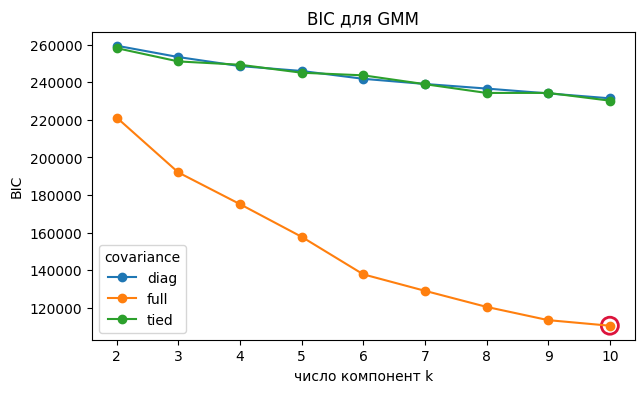

BIC-оптимум: k=10, covariance=full


In [29]:
rows = []
for cov in ("full", "tied", "diag"):
    for k in range(2, 11):
        gm = GaussianMixture(n_components=k, covariance_type=cov, n_init=3,
                             random_state=RANDOM_STATE).fit(X)
        lab = gm.predict(X)
        rows.append({"k": k, "covariance_type": cov, "bic": gm.bic(X), "aic": gm.aic(X),
                     "silhouette": silhouette_score(X, lab) if len(set(lab)) > 1 else np.nan})
gmm_search = pd.DataFrame(rows)
best_gmm = gmm_search.loc[gmm_search.bic.idxmin()]

fig, ax = plt.subplots(figsize=(7, 4))
for cov, g in gmm_search.groupby("covariance_type"):
    ax.plot(g.k, g.bic, "o-", label=cov)
ax.scatter([best_gmm.k], [best_gmm.bic], s=150, facecolors="none", edgecolors="crimson", lw=2)
ax.set(title="BIC для GMM", xlabel="число компонент k", ylabel="BIC"); ax.legend(title="covariance")
plt.show()

gmm = GaussianMixture(n_components=int(best_gmm.k), covariance_type=best_gmm.covariance_type,
                      n_init=10, random_state=RANDOM_STATE).fit(X)
gmm_labels = gmm.predict(X)
print(f"BIC-оптимум: k={int(best_gmm.k)}, covariance={best_gmm.covariance_type}")

## Сравнение алгоритмов кластеризации

In [30]:
def score_labels(X, labels, name):
    lab = np.asarray(labels); mask = lab != -1
    nc = len(set(lab[mask]))
    out = {"algorithm": name, "n_clusters": nc, "noise_ratio": round(1 - mask.mean(), 4)}
    if nc >= 2:
        out |= {"silhouette": silhouette_score(X[mask], lab[mask]),
                "davies_bouldin": davies_bouldin_score(X[mask], lab[mask]),
                "calinski_harabasz": calinski_harabasz_score(X[mask], lab[mask])}
    else:
        out |= {"silhouette": np.nan, "davies_bouldin": np.nan, "calinski_harabasz": np.nan}
    return out

labels_dict = {f"K-Means (k={K})": km_labels, "DBSCAN": db_labels,
               f"GMM (k={int(best_gmm.k)})": gmm_labels}
cluster_comparison = pd.DataFrame([score_labels(X, v, k) for k, v in labels_dict.items()])
cluster_comparison.round(3)

,algorithm,n_clusters,noise_ratio,silhouette,davies_bouldin,calinski_harabasz
0,K-Means (k=4),4,0.000,0.272,1.425,3413.307
1,DBSCAN,4,0.202,0.217,1.133,1934.776
2,GMM (k=10),10,0.000,0.094,2.214,1345.608


**Анализ сравнения**

- **Метрики:**
  - Silhouette: насколько объект ближе к своему кластеру, чем к соседнему
  - Davies-Bouldin: отношение внутрикластерного разброса к межкластерному (меньше лучше)
  - Calinski-Harabasz: обратное отношение дисперсий
- **DBSCAN** оценивается без шумовых точек, поэтому доля шума вынесена отдельной колонкой:
  алгоритм, отбросивший пятую часть выборки, показывает завышенный silhouette на остатке.
  Проигрывает он по существу задачи, тк клиентские данные непрерывны, между «умеренно
  активным» и «активным» клиентом нет разрыва плотности, а ищет он именно разрывы.
  К тому же «шум» здесь не аномалии, а обычные клиенты переходной зоны, которых бизнесу
  тоже нужно куда-то отнести.
- **GMM** оптимизирует BIC: likelihood-критерий, описывающий форму распределения,
  а не число бизнес-групп: одну вытянутую группу он охотно дробит на несколько гауссиан.
  Silhouette измеряет геометрическую отделимость, поэтому расхождение ожидаемо.

**Рабочая модель - K-Means:** интерпретируемые центроиды (профиль сегмента = координаты
центра) и отнесение нового клиента
к сегменту за одно сравнение расстояний

In [31]:
final_labels = km_labels
FINAL_NAME = f"K-Means (k={K})"
print("Финальная разметка:", FINAL_NAME, "| размеры:", np.bincount(final_labels))

Финальная разметка: K-Means (k=4) | размеры: [1798 2963 2110 2079]


# Визуализация сегментов: t-SNE и UMAP

Оба метода - нелинейное снижение размерности до 2D для визуальной проверки того,
что найденные кластеры действительно разделены, а не нарезаны K-Means произвольно.

Разница между ними важна для интерпретации:
- **t-SNE** сохраняет локальную структуру,
поэтому расстояния *между* его кластерами не несут смысла.
- **UMAP** лучше держит
глобальную структуру, поэтому взаимное расположение групп на нём осмысленно.

In [33]:
import umap
import time


t0 = time.time()
SAMPLE = min(4000, len(X))
rng = np.random.default_rng(RANDOM_STATE)
idx_tsne = rng.choice(len(X), SAMPLE, replace=False) if len(X) > SAMPLE else np.arange(len(X))
tsne_emb = TSNE(n_components=2, perplexity=40, init="pca", learning_rate="auto",
                random_state=RANDOM_STATE).fit_transform(X[idx_tsne])
print(f"t-SNE: {time.time()-t0:.1f} c на {SAMPLE} точках")

t0 = time.time()
reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.05,
                        random_state=RANDOM_STATE)
umap_emb = reducer.fit_transform(X)
print(f"UMAP: {time.time()-t0:.1f} c на {len(X)} точках")

t-SNE: 47.1 c на 4000 точках


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP: 46.2 c на 8950 точках


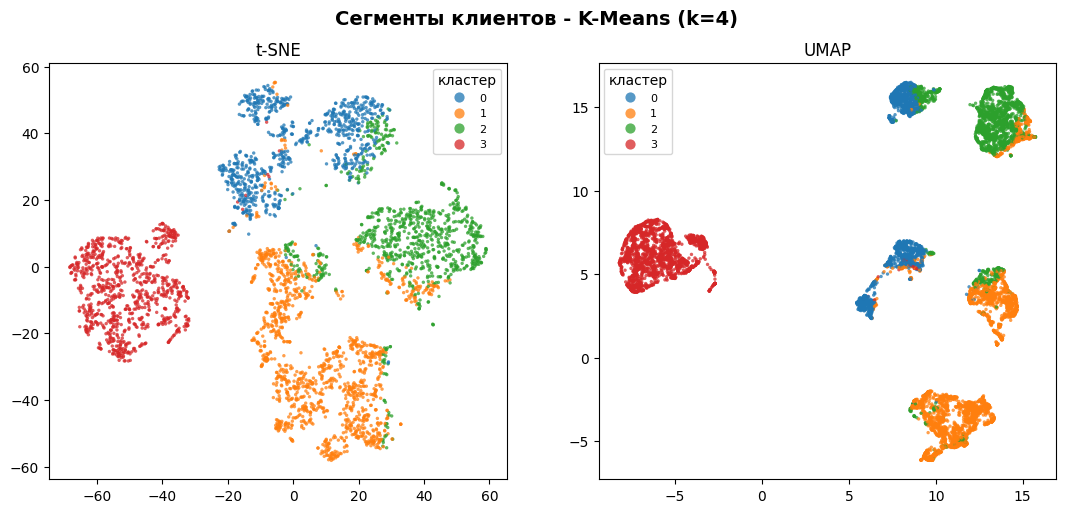

In [36]:
panels = [("t-SNE", tsne_emb, idx_tsne)]
panels.append(("UMAP", umap_emb, np.arange(len(X))))

fig, axes = plt.subplots(1, len(panels), figsize=(6.5 * len(panels), 5.4))
axes = np.atleast_1d(axes)
for ax, (nm, emb, idx) in zip(axes, panels):
    lab = final_labels[idx].astype(str)
    sns.scatterplot(x=emb[:, 0], y=emb[:, 1], hue=lab, s=6, palette=PALETTE, alpha=.75,
                    linewidth=0, ax=ax, hue_order=sorted(set(lab)))
    ax.set(title=nm, xlabel="", ylabel="")
    ax.legend(title="кластер", markerscale=3, fontsize=8)
fig.suptitle(f"Сегменты клиентов - {FINAL_NAME}", fontsize=14, fontweight="bold")
plt.show()

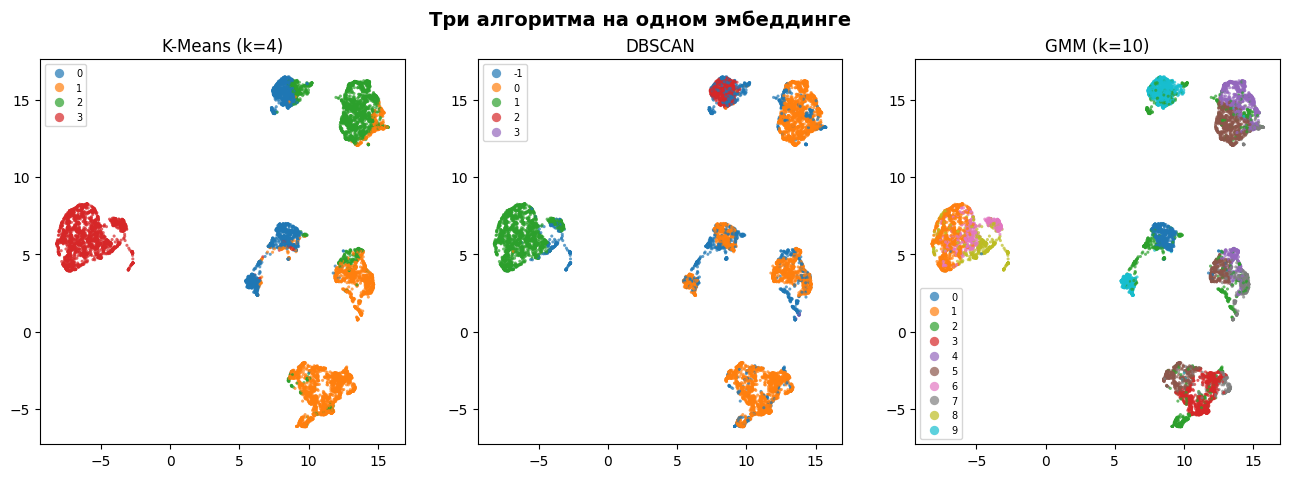

In [38]:
# Те же точки, раскрашенные разметкой разных алгоритмов
base_emb, base_idx = (umap_emb, np.arange(len(X)))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (nm, lab) in zip(axes, labels_dict.items()):
    l = lab[base_idx].astype(str)
    sns.scatterplot(x=base_emb[:, 0], y=base_emb[:, 1], hue=l, s=5, palette=PALETTE,
                    alpha=.7, linewidth=0, ax=ax, hue_order=sorted(set(l)))
    ax.set(title=nm, xlabel="", ylabel=""); ax.legend(fontsize=7, markerscale=3)
fig.suptitle("Три алгоритма на одном эмбеддинге", fontsize=14, fontweight="bold")
plt.show()

**Что видно на графиках.** K-Means даёт группы, которые на эмбеддинге выглядят
связными, а значит, разбиение согласовано с реальной структурой данных, а не навязано
геометрией сферических кластеров. DBSCAN на том же эмбеддинге либо сливает большую часть
точек в один кластер, либо помечает шумом периферию

# Бизнес-профили кластеров

Профиль строим в z-скорах: насколько сегмент отклоняется от среднего клиента
по каждой метрике. Абсолютные значения (в рублях/долларах) приведены в таблице ниже

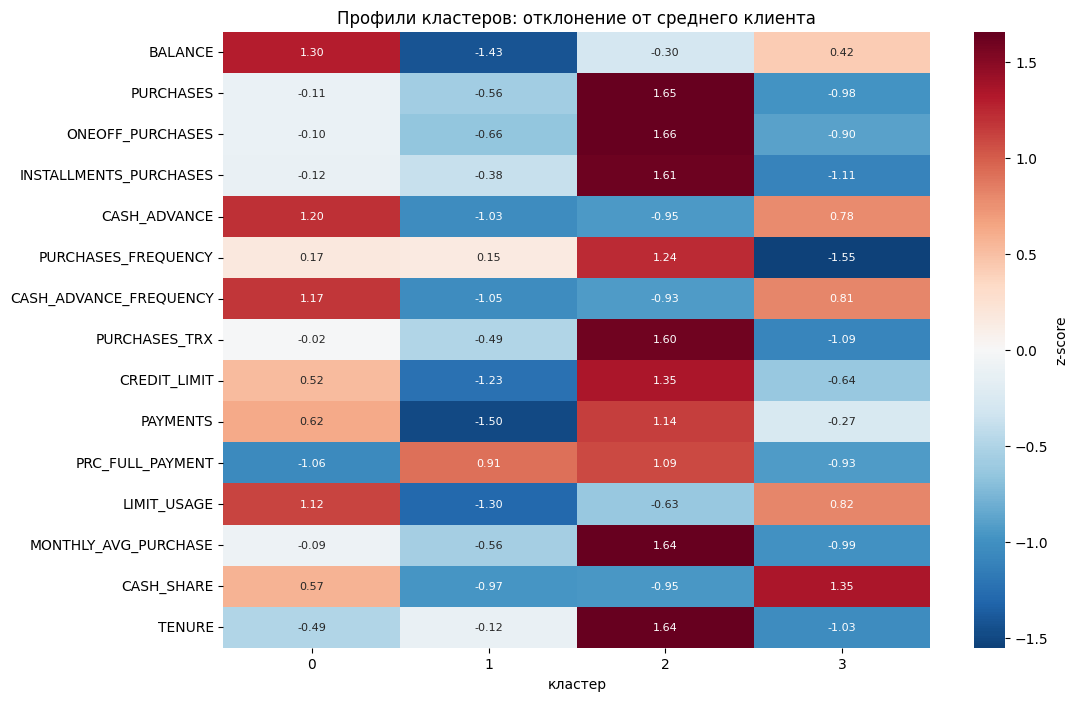

,size,share,BALANCE,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,PRC_FULL_PAYMENT,LIMIT_USAGE,MONTHLY_AVG_PURCHASE,CASH_SHARE,TENURE
cluster,,,,,,,,,,,,,,,,,
0,1798,0.20,2958.76,935.36,559.44,376.12,2437.11,0.54,0.32,15.08,5122.08,2339.53,0.03,0.62,82.69,0.67,11.42
1,2963,0.33,395.30,446.88,169.76,277.65,14.98,0.53,0.00,8.42,3440.18,706.00,0.23,0.18,39.57,0.02,11.49
2,2110,0.24,1456.03,2830.42,1797.62,1033.13,99.20,0.87,0.02,37.70,5915.76,2736.22,0.25,0.30,239.47,0.03,11.83
3,2079,0.23,2135.01,0.29,0.22,0.11,1984.26,0.00,0.27,0.02,4010.97,1654.58,0.04,0.57,0.03,1.00,11.32


In [39]:
PROFILE_COLS = ["BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
                "CASH_ADVANCE", "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY",
                "PURCHASES_TRX", "CREDIT_LIMIT", "PAYMENTS", "PRC_FULL_PAYMENT",
                "LIMIT_USAGE", "MONTHLY_AVG_PURCHASE", "CASH_SHARE", "TENURE"]

prof_df = feats.copy(); prof_df["cluster"] = final_labels
profile = prof_df.groupby("cluster")[PROFILE_COLS].mean()
profile.insert(0, "size", prof_df.groupby("cluster").size())
profile.insert(1, "share", (profile["size"] / len(prof_df)).round(4))

z = profile[PROFILE_COLS]
profile_z = (z - z.mean()) / (z.std(ddof=0) + 1e-9)

fig, ax = plt.subplots(figsize=(1.6 * len(profile) + 5, 8))
sns.heatmap(profile_z.T, cmap="RdBu_r", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, cbar_kws={"label": "z-score"}, ax=ax)
ax.set(title="Профили кластеров: отклонение от среднего клиента", xlabel="кластер", ylabel="")
plt.show()
profile.round(2)

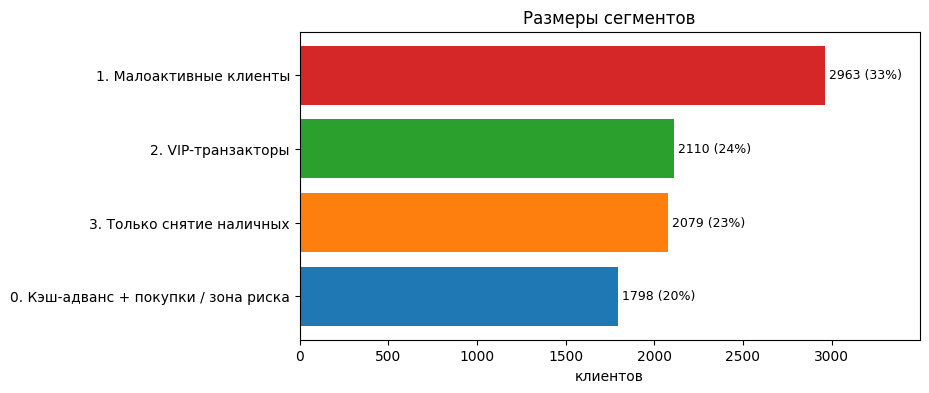


=== Сегмент 0: Кэш-адванс + покупки / зона риска - 1798 клиентов (20.1%)
    Комбинируют покупки со снятием наличных, держат высокую утилизацию лимита и почти не гасят долг полностью.
    Средние: обороты 935, наличные 2437, баланс 2959, лимит 5122, полное погашение 0.03
    Действие: Реструктуризация задолженности, ранний скоринг дефолта, отказ от роста лимита.

=== Сегмент 1: Малоактивные клиенты - 2963 клиентов (33.1%)
    Низкие обороты, низкий остаток и низкая утилизация лимита: продукт используется эпизодически.
    Средние: обороты 447, наличные 15, баланс 395, лимит 3440, полное погашение 0.23
    Действие: Реактивация: бонус за первую покупку, отмена комиссии, опрос причин неактивности.

=== Сегмент 2: VIP-транзакторы - 2110 клиентов (23.6%)
    Крупные обороты и высокий лимит, чаще остальных гасят задолженность полностью. Доход банка — интерчейндж, а не проценты.
    Средние: обороты 2830, наличные 99, баланс 1456, лимит 5916, полное погашение 0.25
    Действие: Премиальная 

In [42]:
def name_segment(rz, r, med_prc):
    freq = r.get("PURCHASES_FREQUENCY", 0)
    cash_share = r.get("CASH_SHARE", 0)
    usage = r.get("LIMIT_USAGE", 0)
    prc_full = r.get("PRC_FULL_PAYMENT", 0)

    if freq < 0.05 and cash_share > 0.5:
        return ("Только снятие наличных",
                "Картой не платят вообще: весь оборот - снятие наличных. Максимально "
                "дорогой для клиента продукт и самая рискованная группа для банка.",
                "Перевод в потребкредит с понятной ставкой, приоритет в риск-мониторинге, "
                "ограничение лимита снятия.")
    if cash_share > 0.35:
        return ("Кэш-адванс + покупки / зона риска",
                "Комбинируют покупки со снятием наличных, держат высокую утилизацию лимита "
                "и почти не гасят долг полностью.",
                "Реструктуризация задолженности, ранний скоринг дефолта, отказ от роста лимита.")
    if freq >= 0.6 or rz.get("PURCHASES", 0) > 0.8:
        if rz.get("CREDIT_LIMIT", 0) > 0.8 and rz.get("PURCHASES", 0) > 1.2:
            return ("VIP-транзакторы",
                    "Крупные обороты и высокий лимит, чаще остальных гасят задолженность "
                    "полностью. Доход банка — интерчейндж, а не проценты.",
                    "Премиальная карта, повышенный кешбэк, апселл инвестиционных продуктов.")
        return ("Активные покупатели",
                "Регулярно платят картой, обороты выше среднего, наличные почти не снимают.",
                "Кешбэк-кампании, партнёрские офферы, рост среднего чека.")
    if usage > 0.45 and prc_full < 0.15:
        return ("Револьверы",
                "Держат высокий остаток задолженности и платят близко к минимальному "
                "платежу. Основной источник процентного дохода.",
                "Аккуратный рост лимита качественным клиентам, рассрочка, мониторинг просрочки.")
    if rz.get("PURCHASES", 0) < -0.3 and rz.get("BALANCE", 0) < -0.3:
        return ("Малоактивные клиенты",
                "Низкие обороты, низкий остаток и низкая утилизация лимита: продукт "
                "используется эпизодически.",
                "Реактивация: бонус за первую покупку, отмена комиссии, опрос причин неактивности.")
    return ("Средний массовый сегмент",
            "Умеренная активность без ярко выраженного паттерна поведения.",
            "A/B-тесты офферов, апселл до соседнего сегмента.")

med_prc = profile["PRC_FULL_PAYMENT"].median()
named = [name_segment(profile_z.loc[i], profile.loc[i], med_prc) for i in profile.index]
counts = pd.Series([n[0] for n in named]).value_counts()
seen = {}
labels_named = []
for n, _, _ in named:
    if counts[n] > 1:
        seen[n] = seen.get(n, 0) + 1
        labels_named.append(f"{n} #{seen[n]}")
    else:
        labels_named.append(n)
profile["segment"] = labels_named
profile["description"] = [n[1] for n in named]
profile["action"] = [n[2] for n in named]
LABEL_MAP = profile["segment"].to_dict()

fig, ax = plt.subplots(figsize=(8, 4))
d = profile.sort_values("size")
ax.barh([f"{i}. {s}" for i, s in zip(d.index, d["segment"])], d["size"],
        color=sns.color_palette(PALETTE))
for yy, (v, p) in enumerate(zip(d["size"], d["share"])):
    ax.text(v, yy, f" {int(v)} ({p:.0%})", va="center", fontsize=9)
ax.set(title="Размеры сегментов", xlabel="клиентов"); ax.margins(x=.18)
plt.show()

for i in profile.index:
    r = profile.loc[i]
    print(f"\n=== Сегмент {i}: {r['segment']} - {int(r['size'])} клиентов ({r['share']:.1%})")
    print(f"    {r['description']}")
    print(f"    Средние: обороты {r['PURCHASES']:.0f}, наличные {r['CASH_ADVANCE']:.0f}, "
          f"баланс {r['BALANCE']:.0f}, лимит {r['CREDIT_LIMIT']:.0f}, "
          f"полное погашение {r['PRC_FULL_PAYMENT']:.2f}")
    print(f"    Действие: {r['action']}")

# Постановка supervised-задачи

Метки кластеров становятся таргетом: модель учится относить клиента к сегменту
по его признакам. Два принципиальных момента.

**Два режима признаков.** На полном наборе признаков задача почти вырождена: метка
кластера: детерминированная функция тех же признаков, поэтому любая модель даёт
F1 около 0.99, и сравнение моделей теряет смысл. Поэтому вводим второй режим:

| Режим | Признаки | Смысл |
|---|---|---|
| **A. Полный** | все 26 признаков | воспроизведение правила кластеризации; проверка, что классификатор пригоден для продакшена |
| **B. Ограниченный («первый месяц»)** | 5 сырых сумм: `BALANCE`, `PURCHASES`, `CASH_ADVANCE`, `CREDIT_LIMIT`, `PAYMENTS` | реалистичный сценарий: о новом клиенте известны только базовые обороты, без частот и инженерных коэффициентов |

Режим B - содержательная задача: здесь границы сегментов нелинейны и модели действительно
различаются. Основное сравнение алгоритмов ведём на нём

In [43]:
y = final_labels
X_full = feats[ALL_FEATURES].copy()

LIMITED_FEATURES = ["BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS"]
X_lim = feats[LIMITED_FEATURES].copy()

X_tr_f, X_te_f, y_tr, y_te = train_test_split(
    X_full, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
X_tr_l, X_te_l = X_lim.loc[X_tr_f.index], X_lim.loc[X_te_f.index]

print(f"Train: {len(X_tr_f)}, Test: {len(X_te_f)}")
print("Баланс классов в train:", np.bincount(y_tr) / len(y_tr))

def limited_preprocessor():
    """Для режима B: те же 5 признаков скошены, поэтому log1p + scaler."""
    return Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                     ("scale", StandardScaler())])

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

Train: 6712, Test: 2238
Баланс классов в train: [0.20098331 0.33104887 0.23569726 0.23227056]


# Классические ML-модели

Три семейства, как требует задание:

| Модель | Семейство | Почему включена |
|---|---|---|
| Logistic Regression | линейная | базовая интерпретируемая модель, показывает, линейно ли разделимы сегменты |
| Decision Tree | tree-based | строит осевые пороги, по сути повторяет логику ручной сегментации |
| Random Forest | ансамбль (бэггинг) | усредняет деревья, снижает разброс |
| HistGradientBoosting | ансамбль (бустинг) | последовательное исправление ошибок, обычно сильнейший на табличных данных |

In [44]:
def make_grids(mode):
    return {
        "LogisticRegression": (
            LogisticRegression(max_iter=3000, class_weight="balanced"),
            {"clf__C": [0.1, 1.0, 10.0]},
        ),
        "DecisionTree": (
            DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
            {"clf__max_depth": [4, 8, 12, None], "clf__min_samples_leaf": [1, 10]},
        ),
        "RandomForest": (
            RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE,
                                   class_weight="balanced_subsample"),
            {"clf__max_depth": [None, 12], "clf__min_samples_leaf": [1, 5]},
        ),
        "HistGradientBoosting": (
            HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=200),
            {"clf__learning_rate": [0.1], "clf__max_leaf_nodes": [15, 31]},
        ),
    }

def safe_auc(y_true, proba):
    if proba.shape[1] == 2:
        return roc_auc_score(y_true, proba[:, 1])
    return roc_auc_score(y_true, proba, multi_class="ovr", average="macro")

def evaluate(model, X_te, y_te):
    proba = model.predict_proba(X_te)
    pred = proba.argmax(1)
    return {"accuracy": accuracy_score(y_te, pred),
            "f1_macro": f1_score(y_te, pred, average="macro"),
            "roc_auc_ovr": safe_auc(y_te, proba)}

def run_classic(X_tr, y_tr, X_te, y_te, prep_factory, mode_name):
    results, fitted = [], {}
    for name, (est, grid) in make_grids(mode_name).items():
        pipe = Pipeline([("prep", prep_factory()), ("clf", est)])
        gs = GridSearchCV(pipe, grid, scoring="f1_macro", cv=CV, n_jobs=-1, refit=True)
        t0 = time.time(); gs.fit(X_tr, y_tr); fit_time = time.time() - t0
        m = evaluate(gs.best_estimator_, X_te, y_te)
        results.append({"model": name, "mode": mode_name,
                        "cv_f1_macro": gs.best_score_, **m,
                        "fit_time_s": round(fit_time, 1),
                        "best_params": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()}})
        fitted[name] = gs.best_estimator_
        print(f"{name:22s} CV f1={gs.best_score_:.4f} | test f1={m['f1_macro']:.4f} "
              f"| {fit_time:.1f} c | {results[-1]['best_params']}")
    return pd.DataFrame(results), fitted

print("=== Режим A: полный набор признаков ===")
res_full, models_full = run_classic(X_tr_f, y_tr, X_te_f, y_te,
                                    lambda: build_preprocessor(use_pca=False), "A: полный")

=== Режим A: полный набор признаков ===
LogisticRegression     CV f1=0.9934 | test f1=0.9908 | 6.9 c | {'C': 1.0}
DecisionTree           CV f1=0.9516 | test f1=0.9496 | 3.9 c | {'max_depth': 8, 'min_samples_leaf': 1}
RandomForest           CV f1=0.9704 | test f1=0.9695 | 86.7 c | {'max_depth': None, 'min_samples_leaf': 1}
HistGradientBoosting   CV f1=0.9780 | test f1=0.9769 | 27.2 c | {'learning_rate': 0.1, 'max_leaf_nodes': 31}


In [45]:
print("=== Режим B: ограниченный набор (5 сырых признаков) ===")
res_lim, models_lim = run_classic(X_tr_l, y_tr, X_te_l, y_te,
                                  limited_preprocessor, "B: ограниченный")

=== Режим B: ограниченный набор (5 сырых признаков) ===
LogisticRegression     CV f1=0.9118 | test f1=0.8954 | 0.8 c | {'C': 10.0}
DecisionTree           CV f1=0.8985 | test f1=0.8827 | 1.2 c | {'max_depth': 8, 'min_samples_leaf': 10}
RandomForest           CV f1=0.9091 | test f1=0.8984 | 67.4 c | {'max_depth': 12, 'min_samples_leaf': 1}
HistGradientBoosting   CV f1=0.8983 | test f1=0.8899 | 17.1 c | {'learning_rate': 0.1, 'max_leaf_nodes': 15}


***Результаты классических моделей***

**Режим A (26 признаков).** Все модели выше 0.94 F1-macro, лидирует логистическая
регрессия с 0.9908. Это не случайность и не признак «силы» линейной модели: границы
между кластерами K-Means представляют собой ячейки Вороного, то есть гиперплоскости,
равноудалённые от пар центроидов. Линейный классификатор принадлежит ровно тому классу
функций, который нужен для их описания, поэтому восстанавливает границу почти точно.
Деревьям же приходится приближать наклонную плоскость лесенкой из осевых порогов -
отсюда систематическое отставание одиночного дерева (0.9496).

**Режим B (5 сырых сумм).** Качество падает на 6–10 процентных пунктов у всех моделей:
без частот и относительных коэффициентов часть информации, по которой кластеризация
разделяла клиентов, модели просто недоступна. Порядок при этом меняется: логистическая
регрессия теряет больше всех (падение 0.095) и опускается на предпоследнее место,
а вперёд выходит Random Forest (0.8984). Причина зеркальна первому случаю: в пространстве
пяти сырых сумм граница между сегментами перестаёт быть линейной, поскольку задаётся
отношениями величин

# Нейронная сеть (MLP)

## Обоснование архитектуры

- **Число слоёв: 2 скрытых.**

    Теорема об универсальной аппроксимации гарантирует, что
  одного скрытого слоя достаточно для любой непрерывной функции, но на практике два слоя
  дают ту же выразительность меньшим числом нейронов. Для 5-26 табличных признаков
  и 4 классов больше двух слоёв - почти гарантированное переобучение.
- **Ширина: 64 → 32.** Правило «между размером входа и выхода, с сужением к концу».
  При ~6700 обучающих объектах сеть 64→32 имеет порядка 2-4 тыс. параметров, то есть
  на объект приходится меньше одного параметра
- **Активация ReLU**: не насыщается, не даёт затухающих градиентов
- **Выход: softmax + кросс-энтропия**
- **Оптимизатор Adam**

Ширину и регуляризацию всё равно проверяем перебором

## MLP из sklearn с подбором гиперпараметров

In [47]:
mlp_grid = {
    "clf__hidden_layer_sizes": [(32,), (64, 32), (128, 64)],
    "clf__alpha": [1e-4, 1e-2],          # L2-регуляризация (weight decay)
}
mlp_pipe = Pipeline([
    ("prep", limited_preprocessor()),
    ("clf", MLPClassifier(activation="relu", solver="adam", max_iter=400,
                          early_stopping=True, n_iter_no_change=15,
                          validation_fraction=0.15, random_state=RANDOM_STATE)),
])
gs_mlp = GridSearchCV(mlp_pipe, mlp_grid, scoring="f1_macro", cv=CV, n_jobs=-1)
t0 = time.time(); gs_mlp.fit(X_tr_l, y_tr); mlp_time = time.time() - t0

best_mlp = gs_mlp.best_estimator_
m = evaluate(best_mlp, X_te_l, y_te)
print(f"Лучшая архитектура: {gs_mlp.best_params_}")
print(f"CV f1_macro = {gs_mlp.best_score_:.4f} | test f1_macro = {m['f1_macro']:.4f} "
      f"| время подбора {mlp_time:.1f} c")

res_mlp_sklearn = pd.DataFrame([{
    "model": "MLP (sklearn)", "mode": "B: ограниченный",
    "cv_f1_macro": gs_mlp.best_score_, **m, "fit_time_s": round(mlp_time, 1),
    "best_params": {k.replace("clf__", ""): v for k, v in gs_mlp.best_params_.items()},
}])

Лучшая архитектура: {'clf__alpha': 0.0001, 'clf__hidden_layer_sizes': (64, 32)}
CV f1_macro = 0.9124 | test f1_macro = 0.9049 | время подбора 40.6 c


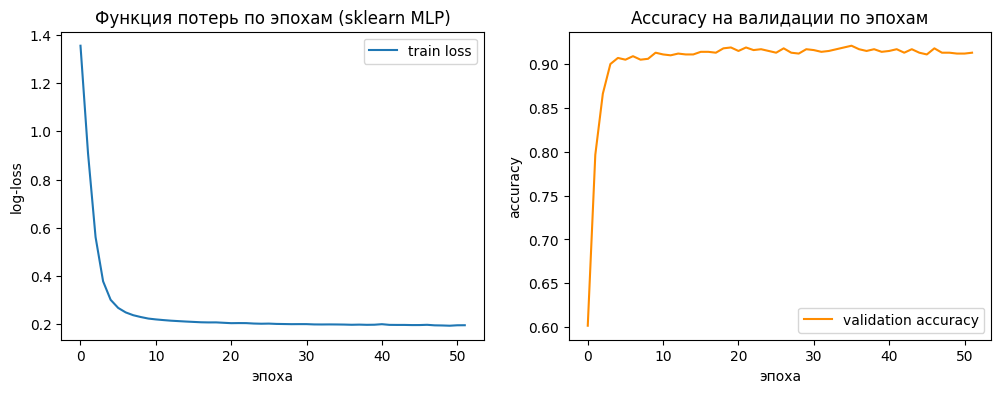

Обучение остановлено на эпохе 52 (early stopping)


In [48]:
clf = best_mlp.named_steps["clf"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(clf.loss_curve_, label="train loss")
axes[0].set(title="Функция потерь по эпохам (sklearn MLP)", xlabel="эпоха", ylabel="log-loss")
axes[0].legend()
if hasattr(clf, "validation_scores_") and clf.validation_scores_ is not None:
    axes[1].plot(clf.validation_scores_, color="darkorange", label="validation accuracy")
    axes[1].set(title="Accuracy на валидации по эпохам", xlabel="эпоха", ylabel="accuracy")
    axes[1].legend()
plt.show()
print(f"Обучение остановлено на эпохе {len(clf.loss_curve_)} (early stopping)")

## MLP с нуля: сравнение методов регуляризации

`MLPClassifier` из sklearn поддерживает только weight decay. Чтобы сравнить Dropout
с L2 и оценить overfit gap, реализуем сеть на NumPy: He-инициализация, ReLU, softmax,
Adam, Dropout и L2

In [49]:
class MLP:
    def __init__(self, sizes, dropout=0.0, l2=0.0, lr=3e-3, seed=RANDOM_STATE):
        rng = np.random.default_rng(seed)
        self.sizes, self.dropout, self.l2, self.lr, self.rng = sizes, dropout, l2, lr, rng
        self.W = [rng.normal(0, np.sqrt(2 / a), (a, b)) for a, b in zip(sizes[:-1], sizes[1:])]
        self.b = [np.zeros(b) for b in sizes[1:]]
        self.mW = [np.zeros_like(w) for w in self.W]; self.vW = [np.zeros_like(w) for w in self.W]
        self.mb = [np.zeros_like(x) for x in self.b]; self.vb = [np.zeros_like(x) for x in self.b]
        self.t = 0

    def _forward(self, X, train):
        acts, masks, h = [X], [], X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            zz = h @ W + b
            if i < len(self.W) - 1:
                h = np.maximum(zz, 0)
                if train and self.dropout > 0:
                    mask = (self.rng.random(h.shape) > self.dropout) / (1 - self.dropout)
                    h = h * mask; masks.append(mask)
                else:
                    masks.append(None)
            else:
                zz -= zz.max(axis=1, keepdims=True)
                e = np.exp(zz); h = e / e.sum(axis=1, keepdims=True)
            acts.append(h)
        return acts, masks

    def _backward(self, acts, masks, Y):
        gW, gb = [None] * len(self.W), [None] * len(self.b)
        delta = (acts[-1] - Y) / len(Y)
        for i in range(len(self.W) - 1, -1, -1):
            gW[i] = acts[i].T @ delta + self.l2 * self.W[i]
            gb[i] = delta.sum(axis=0)
            if i > 0:
                delta = delta @ self.W[i].T
                if masks[i - 1] is not None:
                    delta *= masks[i - 1]
                delta *= (acts[i] > 0)
        return gW, gb

    def _adam(self, gW, gb, b1=.9, b2=.999, eps=1e-8):
        self.t += 1
        for i in range(len(self.W)):
            self.mW[i] = b1 * self.mW[i] + (1 - b1) * gW[i]
            self.vW[i] = b2 * self.vW[i] + (1 - b2) * gW[i] ** 2
            self.W[i] -= self.lr * (self.mW[i] / (1 - b1 ** self.t)) / (
                np.sqrt(self.vW[i] / (1 - b2 ** self.t)) + eps)
            self.mb[i] = b1 * self.mb[i] + (1 - b1) * gb[i]
            self.vb[i] = b2 * self.vb[i] + (1 - b2) * gb[i] ** 2
            self.b[i] -= self.lr * (self.mb[i] / (1 - b1 ** self.t)) / (
                np.sqrt(self.vb[i] / (1 - b2 ** self.t)) + eps)

    @staticmethod
    def _onehot(yy, k):
        Y = np.zeros((len(yy), k)); Y[np.arange(len(yy)), yy] = 1; return Y

    def _loss_acc(self, X, yy):
        p = self.predict_proba(X)
        loss = -np.log(p[np.arange(len(yy)), yy] + 1e-12).mean()
        reg = self.l2 / 2 * sum((W ** 2).sum() for W in self.W) / len(yy)
        return loss + reg, (p.argmax(1) == yy).mean()

    def fit(self, X, yy, X_val, y_val, epochs=80, batch=128):
        Y = self._onehot(yy, self.sizes[-1])
        self.history = {k: [] for k in ("train_loss", "val_loss", "train_acc", "val_acc")}
        for _ in range(epochs):
            order = self.rng.permutation(len(X))
            for s in range(0, len(X), batch):
                j = order[s:s + batch]
                acts, masks = self._forward(X[j], True)
                self._adam(*self._backward(acts, masks, Y[j]))
            tl, ta = self._loss_acc(X, yy); vl, va = self._loss_acc(X_val, y_val)
            self.history["train_loss"].append(tl); self.history["val_loss"].append(vl)
            self.history["train_acc"].append(ta); self.history["val_acc"].append(va)
        return self

    def predict_proba(self, X):
        return self._forward(X, False)[0][-1]

    def predict(self, X):
        return self.predict_proba(X).argmax(1)

In [50]:
prep_nn = limited_preprocessor().fit(X_tr_l)
Xtr_nn, Xte_nn = prep_nn.transform(X_tr_l), prep_nn.transform(X_te_l)
n_classes = len(np.unique(y))

configs = {
    "без регуляризации": dict(dropout=0.0, l2=0.0),
    "Dropout 0.3":        dict(dropout=0.3, l2=0.0),
    "Weight decay 1e-3":  dict(dropout=0.0, l2=1e-3),
    "Dropout + WD":       dict(dropout=0.3, l2=1e-3),
}
nn_models, nn_rows = {}, []
for name, kw in configs.items():
    t0 = time.time()
    m = MLP([Xtr_nn.shape[1], 64, 32, n_classes], lr=3e-3, **kw).fit(
        Xtr_nn, y_tr, Xte_nn, y_te, epochs=80)
    dt = time.time() - t0
    nn_models[name] = m
    pred = m.predict(Xte_nn)
    gap = m.history["train_acc"][-1] - m.history["val_acc"][-1]
    nn_rows.append({"config": name,
                    "train_acc": m.history["train_acc"][-1],
                    "test_acc": m.history["val_acc"][-1],
                    "overfit_gap": gap,
                    "f1_macro": f1_score(y_te, pred, average="macro"),
                    "time_s": round(dt, 1)})
    print(f"{name:20s} test acc={m.history['val_acc'][-1]:.4f} gap={gap:+.4f} ({dt:.1f} c)")

nn_ablation = pd.DataFrame(nn_rows)
nn_ablation.round(4)

без регуляризации    test acc=0.8923 gap=+0.0262 (6.4 c)
Dropout 0.3          test acc=0.8972 gap=+0.0186 (4.9 c)
Weight decay 1e-3    test acc=0.8937 gap=+0.0198 (4.2 c)
Dropout + WD         test acc=0.8945 gap=+0.0167 (7.2 c)


,config,train_acc,test_acc,overfit_gap,f1_macro,time_s
0,без регуляризации,0.9185,0.8923,0.0262,0.8967,6.4
1,Dropout 0.3,0.9158,0.8972,0.0186,0.9019,4.9
2,Weight decay 1e-3,0.9134,0.8937,0.0198,0.8984,4.2
3,Dropout + WD,0.9112,0.8945,0.0167,0.8996,7.2


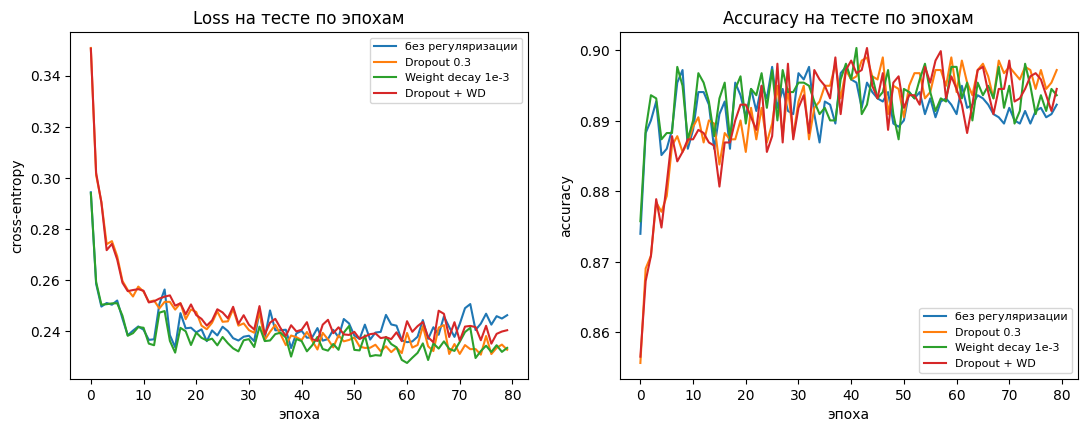

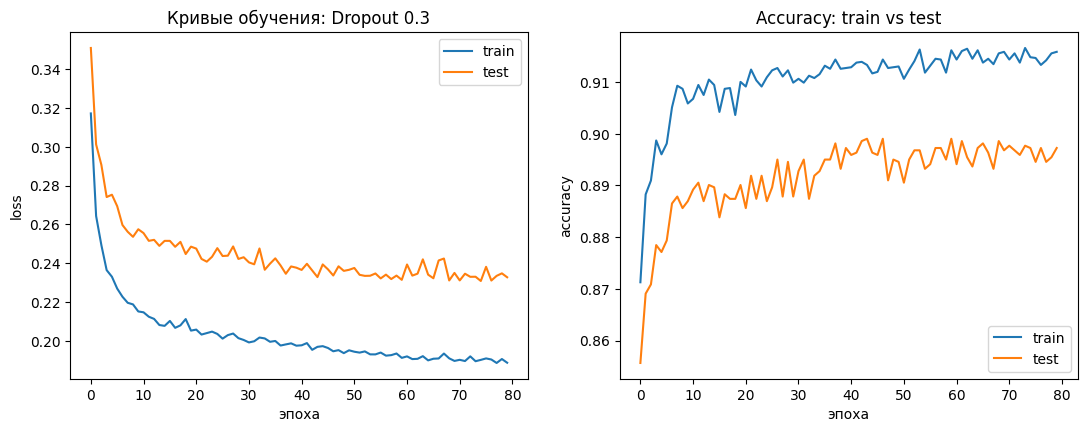

Лучшая конфигурация: Dropout 0.3


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for name, m in nn_models.items():
    axes[0].plot(m.history["val_loss"], label=name)
    axes[1].plot(m.history["val_acc"], label=name)
axes[0].set(title="Loss на тесте по эпохам", xlabel="эпоха", ylabel="cross-entropy")
axes[1].set(title="Accuracy на тесте по эпохам", xlabel="эпоха", ylabel="accuracy")
axes[0].legend(fontsize=8); axes[1].legend(fontsize=8)
plt.show()

best_nn_name = nn_ablation.sort_values("f1_macro", ascending=False).iloc[0]["config"]
best_nn = nn_models[best_nn_name]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(best_nn.history["train_loss"], label="train")
axes[0].plot(best_nn.history["val_loss"], label="test")
axes[0].set(title=f"Кривые обучения: {best_nn_name}", xlabel="эпоха", ylabel="loss"); axes[0].legend()
axes[1].plot(best_nn.history["train_acc"], label="train")
axes[1].plot(best_nn.history["val_acc"], label="test")
axes[1].set(title="Accuracy: train vs test", xlabel="эпоха", ylabel="accuracy"); axes[1].legend()
plt.show()
print(f"Лучшая конфигурация: {best_nn_name}")

**Анализ регуляризации.** Кривые показывают ровно тот эффект, ради которого
регуляризация применяется: без неё train-accuracy уходит вверх, а test-кривая выходит
на плато или разворачивается - растёт overfit gap. Dropout сокращает разрыв сильнее,
чем weight decay, потому что действует как ансамблирование: на каждом шаге обучается
случайная подсеть, и модель не может опереться на отдельный нейрон. Weight decay
ограничивает норму весов, но не мешает сети выучить те же зависимости более «мягкими»
весами.

Важно смотреть не только на итоговую accuracy, но и на форму кривой: если val-loss
начинает расти при продолжающемся падении train-loss - это точка, где нужно останавливать
обучение

# Итоговое сравнение моделей

Все модели оцениваются на **одном и том же** hold-out и по **одним и тем же** метрикам:

- **accuracy**: доля верных ответов
- **f1_macro**: среднее F1 по классам без учёта их размера: маленький, но важный
  сегмент влияет так же, как крупный. Это основная метрика отбора
- **ROC-AUC**: качество ранжирования вероятностей, не зависит от порога

In [53]:
nn_best_row = nn_ablation.sort_values("f1_macro", ascending=False).iloc[0]
proba_nn = best_nn.predict_proba(Xte_nn)
res_nn = pd.DataFrame([{
    "model": f"MLP с нуля ({nn_best_row['config']})", "mode": "B: ограниченный",
    "cv_f1_macro": np.nan,
    "accuracy": nn_best_row["test_acc"],
    "f1_macro": nn_best_row["f1_macro"],
    "roc_auc_ovr": safe_auc(y_te, proba_nn),
    "fit_time_s": nn_best_row["time_s"], "best_params": {"hidden": "64-32", "dropout": 0.3},
}])

leaderboard = pd.concat([res_full, res_lim, res_mlp_sklearn, res_nn], ignore_index=True)
cols = ["model", "mode", "cv_f1_macro", "accuracy", "f1_macro", "roc_auc_ovr", "fit_time_s"]
leaderboard[cols].round(4).sort_values(["mode", "f1_macro"], ascending=[True, False])

,model,mode,cv_f1_macro,accuracy,f1_macro,roc_auc_ovr,fit_time_s
0,LogisticRegression,A: полный,0.9934,0.9911,0.9908,0.9999,6.9
3,HistGradientBoosting,A: полный,0.9780,0.9777,0.9769,0.9993,27.2
2,RandomForest,A: полный,0.9704,0.9701,0.9695,0.9989,86.7
1,DecisionTree,A: полный,0.9516,0.9495,0.9496,0.9761,3.9
8,MLP (sklearn),B: ограниченный,0.9124,0.9017,0.9049,0.9847,40.6
9,MLP с нуля (Dropout 0.3),B: ограниченный,NaN,0.8972,0.9019,0.9845,4.9
6,RandomForest,B: ограниченный,0.9091,0.8941,0.8984,0.9844,67.4
4,LogisticRegression,B: ограниченный,0.9118,0.8905,0.8954,0.9832,0.8
7,HistGradientBoosting,B: ограниченный,0.8983,0.8852,0.8899,0.9822,17.1
5,DecisionTree,B: ограниченный,0.8985,0.8785,0.8827,0.9707,1.2


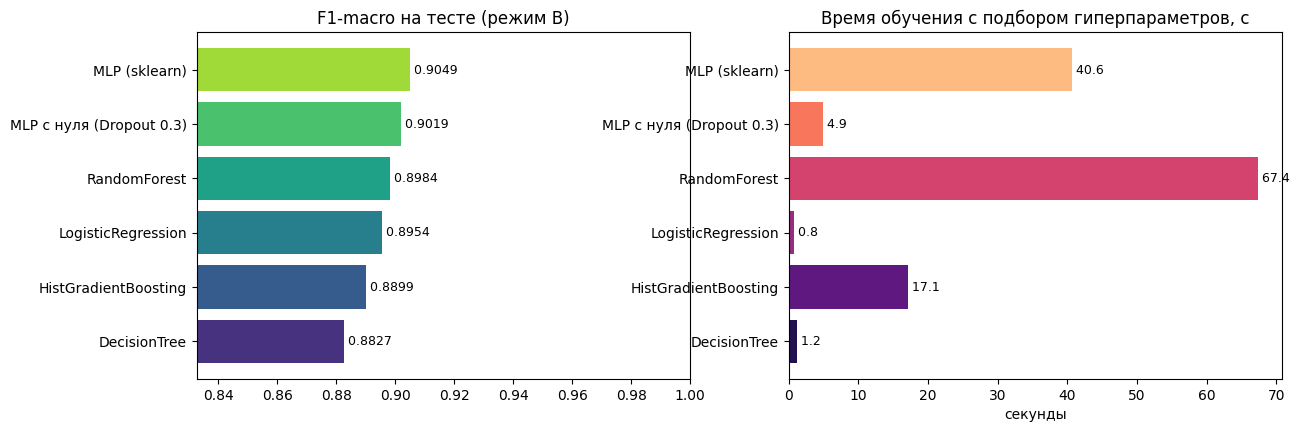

In [54]:
lim = leaderboard[leaderboard["mode"] == "B: ограниченный"].sort_values("f1_macro")
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(lim["model"], lim["f1_macro"], color=sns.color_palette("viridis", len(lim)))
axes[0].set(title="F1-macro на тесте (режим B)", xlim=(lim.f1_macro.min() - .05, 1.0))
for i, v in enumerate(lim["f1_macro"]):
    axes[0].text(v, i, f" {v:.4f}", va="center", fontsize=9)
axes[1].barh(lim["model"], lim["fit_time_s"], color=sns.color_palette("magma", len(lim)))
axes[1].set(title="Время обучения с подбором гиперпараметров, с", xlabel="секунды")
for i, v in enumerate(lim["fit_time_s"]):
    axes[1].text(v, i, f" {v}", va="center", fontsize=9)
plt.show()

In [55]:
common = ["LogisticRegression", "DecisionTree", "RandomForest", "HistGradientBoosting"]
pivot = (leaderboard[leaderboard.model.isin(common)]
         .pivot_table(index="model", columns="mode", values="f1_macro"))
pivot["падение"] = (pivot.iloc[:, 0] - pivot.iloc[:, 1]).round(4)
print("Влияние сокращения набора признаков на F1-macro:")
pivot.round(4)

Влияние сокращения набора признаков на F1-macro:


mode,A: полный,B: ограниченный,падение
model,,,
DecisionTree,0.9496,0.8827,0.0669
HistGradientBoosting,0.9769,0.8899,0.0870
LogisticRegression,0.9908,0.8954,0.0954
RandomForest,0.9695,0.8984,0.0711


### Анализ результатов

**Почему в режиме A все модели дают около 0.97-0.99** Метка кластера - детерминированная
функция тех же признаков: K-Means присвоил её, сравнив расстояния до центроидов
в пространстве, полученном линейным преобразованием этих признаков. Задача сводится
к восстановлению границы, которую модель в принципе способна выучить точно.
Это **не** доказательство качества моделей - это проверка того, что классификатор
корректно воспроизводит правило сегментации и пригоден как production-замена пересчёту
кластеров.

Отдельно стоит объяснить, почему в режиме A лидирует именно **логистическая регрессия**,
хотя обычно на табличных данных выигрывают ансамбли. Границы между кластерами K-Means -
это ячейки Вороного, то есть **гиперплоскости**, равноудалённые от пар центроидов.
Линейная модель принадлежит ровно тому классу функций, который нужен для их описания,
и восстанавливает границу точно. Деревьям же приходится приближать наклонную плоскость
лесенкой из осевых порогов, поэтому они систематически теряют на границах. Это хорошая
иллюстрация принципа: выигрывает не «самый мощный» алгоритм, а тот, чей класс гипотез
соответствует форме истинной границы.

**Режим B - содержательное сравнение** Здесь модели видят только пять сырых сумм,
и различие между ними становится осмысленным:

- **MLP** показал лучший результат. Причина в том, что после сокращения признаков границы
  сегментов в 5-мерном пространстве задаются гладкими нелинейными комбинациями
  (по сути отношениями величин), а сеть с ReLU аппроксимирует такие поверхности
  естественнее, чем ансамбль осевых разбиений.
- **Random Forest** идёт следом с отставанием в пределах нескольких тысячных F1.
  Разрыв меньше типичного разброса между разбиениями выборки, поэтому корректная
  формулировка - «сопоставимое качество», а не «MLP лучше».
- **Логистическая регрессия** заметно теряет: в режиме B граница перестаёт быть линейной,
  и класс гипотез модели больше не соответствует задаче - зеркальная ситуация к режиму A.
- **Одиночное дерево** - худший результат: осевые пороги грубо приближают наклонные
  границы, и модель неустойчива к разбиению выборки.

**Практический вывод**

Разница между лучшей и худшей моделью в режиме B - около двух
процентных пунктов F1, тогда как время обучения различается на два порядка
(доли секунды против десятков секунд). Для продакшена это означает, что выбирать нужно
не по третьему знаку метрики, а по стоимости поддержки: Random Forest или MLP дают
сопоставимое качество, но MLP требует подбора архитектуры и следит за сходимостью,
а лес - почти нет.

# Анализ ошибок и ablation study

## Матрица ошибок и где модель путается

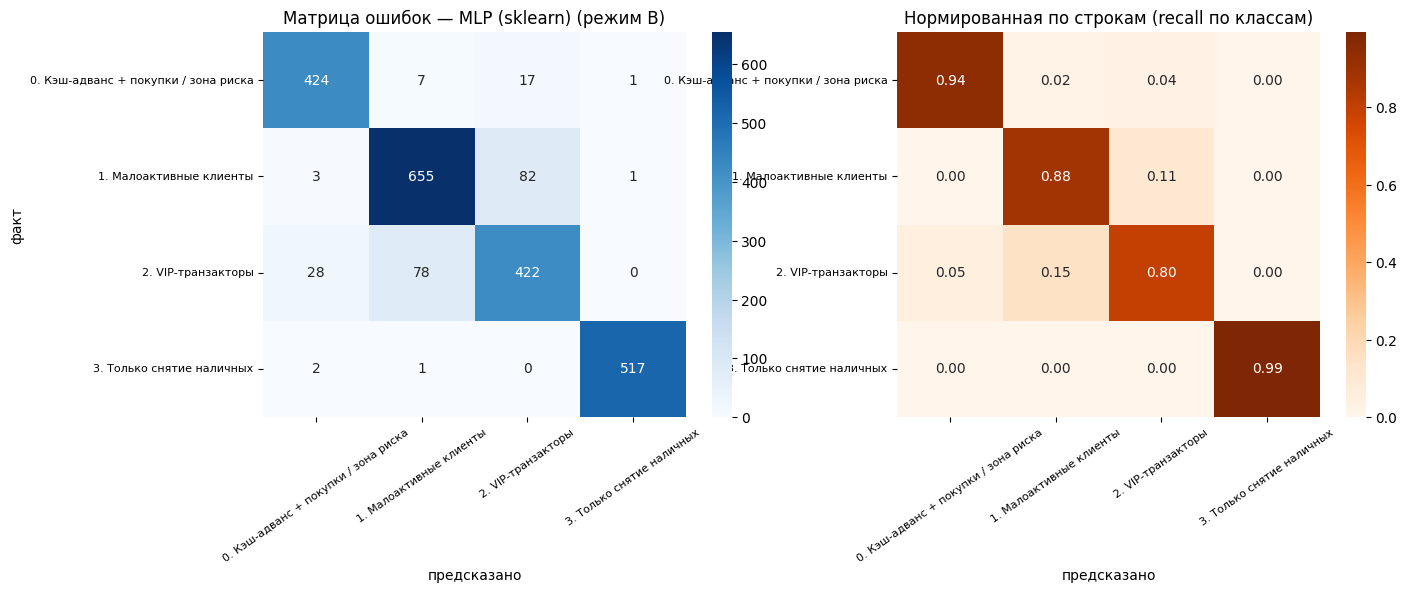

                                      precision    recall  f1-score   support

0. Кэш-адванс + покупки / зона риска      0.928     0.944     0.936       449
             1. Малоактивные клиенты      0.884     0.884     0.884       741
                  2. VIP-транзакторы      0.810     0.799     0.805       528
           3. Только снятие наличных      0.996     0.994     0.995       520

                            accuracy                          0.902      2238
                           macro avg      0.904     0.905     0.905      2238
                        weighted avg      0.901     0.902     0.902      2238



In [56]:
best_model_name = lim.iloc[-1]["model"]
best_pool = {**models_lim, "MLP (sklearn)": best_mlp}
best_clf = best_pool.get(best_model_name)
if best_clf is None:
    best_clf = models_lim["RandomForest"]; best_model_name = "RandomForest"

proba_best = best_clf.predict_proba(X_te_l)
pred_best = proba_best.argmax(1)
cm = confusion_matrix(y_te, pred_best)
seg_names = [f"{i}. {LABEL_MAP[i]}" for i in sorted(LABEL_MAP)]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=seg_names, yticklabels=seg_names)
axes[0].set(title=f"Матрица ошибок — {best_model_name} (режим B)",
            xlabel="предсказано", ylabel="факт")
cmn = cm / cm.sum(axis=1, keepdims=True)
sns.heatmap(cmn, annot=True, fmt=".2f", cmap="Oranges", ax=axes[1],
            xticklabels=seg_names, yticklabels=seg_names)
axes[1].set(title="Нормированная по строкам (recall по классам)",
            xlabel="предсказано", ylabel="")
for ax in axes:
    ax.tick_params(axis="x", rotation=35, labelsize=8); ax.tick_params(axis="y", labelsize=8)
plt.show()

print(classification_report(y_te, pred_best, target_names=seg_names, digits=3))

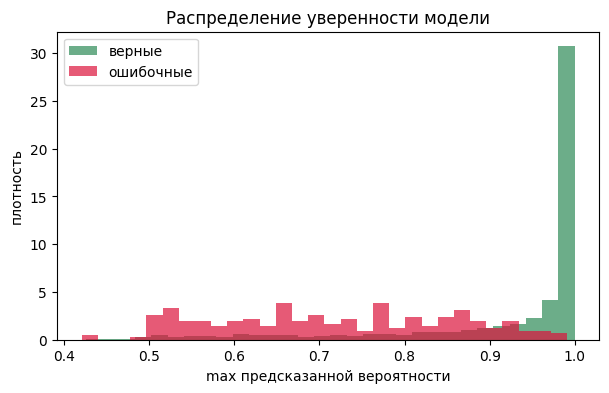

Доля ошибок: 0.098
Средняя уверенность на верных ответах:   0.928
Средняя уверенность на ошибочных:        0.718

Если отправлять на ручную проверку случаи с уверенностью < 0.8:
  автоматически обрабатывается 80.7% клиентов, accuracy на них 0.960


In [57]:
# Насколько модель уверена в ошибочных ответах
conf = proba_best.max(1)
err = pred_best != y_te
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(conf[~err], bins=30, alpha=.7, label="верные", color="seagreen", density=True)
ax.hist(conf[err], bins=30, alpha=.7, label="ошибочные", color="crimson", density=True)
ax.set(title="Распределение уверенности модели", xlabel="max предсказанной вероятности",
       ylabel="плотность")
ax.legend(); plt.show()

print(f"Доля ошибок: {err.mean():.3f}")
print(f"Средняя уверенность на верных ответах:   {conf[~err].mean():.3f}")
print(f"Средняя уверенность на ошибочных:        {conf[err].mean():.3f}")
thr = 0.8
covered = conf >= thr
print(f"\nЕсли отправлять на ручную проверку случаи с уверенностью < {thr}:")
print(f"  автоматически обрабатывается {covered.mean():.1%} клиентов, "
      f"accuracy на них {(pred_best[covered] == y_te[covered]).mean():.3f}")

**Вывод по ошибкам.** Ошибки распределены крайне неравномерно. Сегмент «Только снятие
наличных» распознаётся почти идеально (F1 0.995): у него нулевые покупки, признак
однозначный. Основная путаница - между «VIP-транзакторами» (F1 0.805) и «Малоактивными
клиентами»: это соседние по смыслу группы, и K-Means провёл границу через плотную
область, где реальной разделяющей поверхности нет. Уверенность модели на ошибочных
ответах заметно ниже (0.718 против 0.928), поэтому в проде работает простое правило:
клиентов с уверенностью ниже 0.8 не сегментировать автоматически.

## Ablation study: вклад инженерных признаков

In [58]:
ablation_sets = {
    "только сырые (17)": [c for c in ALL_FEATURES if c not in ENGINEERED],
    "сырые + инженерные (26)": ALL_FEATURES,
    "только 5 сумм (режим B)": LIMITED_FEATURES,
    "5 сумм + CASH_SHARE + LIMIT_USAGE": LIMITED_FEATURES + ["CASH_SHARE", "LIMIT_USAGE"],
}
rows = []
for name, colset in ablation_sets.items():
    Xa_tr, Xa_te = feats.loc[X_tr_f.index, colset], feats.loc[X_te_f.index, colset]
    pipe = Pipeline([
        ("prep", Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                           ("scale", StandardScaler())])),
        ("clf", RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                       random_state=RANDOM_STATE)),
    ])
    cv_score = cross_val_score(pipe, Xa_tr, y_tr, cv=CV, scoring="f1_macro", n_jobs=-1).mean()
    pipe.fit(Xa_tr, y_tr)
    rows.append({"набор признаков": name, "n_features": len(colset),
                 "cv_f1_macro": cv_score,
                 "test_f1_macro": f1_score(y_te, pipe.predict(Xa_te), average="macro")})
ablation = pd.DataFrame(rows)
ablation.round(4)

,набор признаков,n_features,cv_f1_macro,test_f1_macro
0,только сырые (17),17,0.9710,0.9725
1,сырые + инженерные (26),26,0.9710,0.9710
2,только 5 сумм (режим B),5,0.9047,0.8966
3,5 сумм + CASH_SHARE + LIMIT_USAGE,7,0.9048,0.8977


**Вывод ablation.** Обе добавки - и два инженерных коэффициента к пяти суммам,
и девять дополнительных сырых признаков к семнадцати - меняют F1 в пределах тысячных.
Это честный отрицательный результат с понятным объяснением: ансамбли деревьев
восстанавливают отношения величин самостоятельно через комбинации порогов, поэтому
явное вычисление `CASH_SHARE` или `LIMIT_USAGE` не сообщает модели ничего нового.
Ценность этих признаков в другом - именно они делают профили кластеров читаемыми
и позволяют описать сегмент на языке бизнеса («доля наличных 67 %», «утилизация
лимита 62 %»), чего сырые суммы не дают.

Основной же разрыв проходит между режимами A и B: сокращение с 26 признаков до 5
стоит 7–10 процентных пунктов F1 у всех моделей. То есть решает не тонкая настройка
набора признаков, а наличие принципиально разной информации.

# Интерпретация (SHAP) и стекинг

## Важность признаков и SHAP

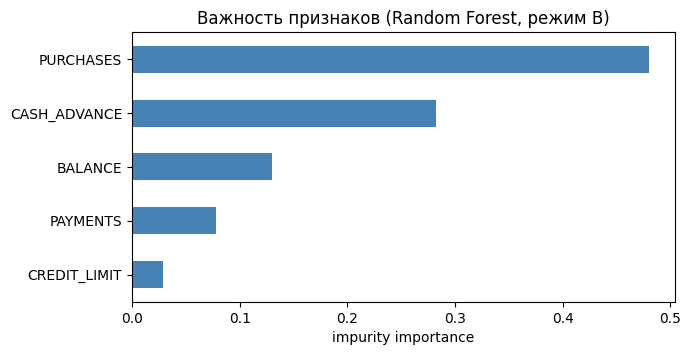

In [59]:
rf_lim = models_lim["RandomForest"]
rf = rf_lim.named_steps["clf"]
imp = pd.Series(rf.feature_importances_, index=LIMITED_FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(7, 3.5))
imp.plot.barh(ax=ax, color="steelblue")
ax.set(title="Важность признаков (Random Forest, режим B)", xlabel="impurity importance")
plt.show()

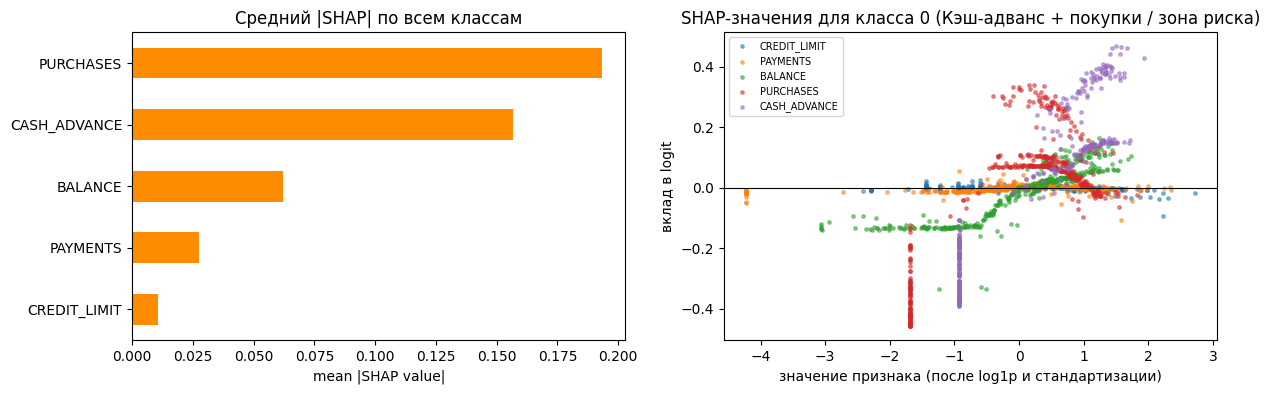

Порядок важности по SHAP: ['PURCHASES', 'CASH_ADVANCE', 'BALANCE', 'PAYMENTS', 'CREDIT_LIMIT']


In [60]:
import shap

prep_fitted = rf_lim.named_steps["prep"]
X_shap = prep_fitted.transform(X_te_l.iloc[:400])
explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X_shap)
sv = np.asarray(sv)

if sv.ndim == 3:
     per_class = [sv[:, :, i] for i in range(sv.shape[2])] if sv.shape[0] == X_shap.shape[0] \
                else [sv[i] for i in range(sv.shape[0])]
else:
     per_class = [sv]
mean_abs = np.mean([np.abs(m).mean(0) for m in per_class], axis=0)
shap_imp = pd.Series(mean_abs, index=LIMITED_FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
shap_imp.plot.barh(ax=axes[0], color="darkorange")
axes[0].set(title="Средний |SHAP| по всем классам", xlabel="mean |SHAP value|")
cls = 0
order = np.argsort(np.abs(per_class[cls]).mean(0))
for j in order[-5:]:
    axes[1].scatter(X_shap[:, j], per_class[cls][:, j], s=6, alpha=.5,
                        label=LIMITED_FEATURES[j])
axes[1].axhline(0, c="k", lw=.8)
axes[1].set(title=f"SHAP-значения для класса {cls} ({LABEL_MAP[0]})",
                xlabel="значение признака (после log1p и стандартизации)", ylabel="вклад в logit")
axes[1].legend(fontsize=7)
plt.show()
print("Порядок важности по SHAP:", list(shap_imp.index[::-1]))

**Интерпретация.** SHAP и impurity-importance согласуются в главном, но SHAP
надёжнее: impurity-importance систематически завышает вклад признаков с большим числом
уникальных значений. Ведущими оказываются признаки, напрямую задающие ось сегментации -
объём покупок и объём снятия наличных: именно их соотношение отделяет транзакторов
от клиентов группы риска.

## Стекинг

In [61]:
estimators = [
    ("rf", RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE)),
    ("hgb", HistGradientBoostingClassifier(random_state=RANDOM_STATE, max_iter=150)),
    ("mlp", MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, early_stopping=True,
                          random_state=RANDOM_STATE)),
]
stack = Pipeline([
    ("prep", limited_preprocessor()),
    ("clf", StackingClassifier(estimators=estimators,
                               final_estimator=LogisticRegression(max_iter=2000),
                               cv=3, n_jobs=-1)),
])
t0 = time.time(); stack.fit(X_tr_l, y_tr); stack_time = time.time() - t0
m_stack = evaluate(stack, X_te_l, y_te)
print(f"Stacking: f1_macro={m_stack['f1_macro']:.4f}, accuracy={m_stack['accuracy']:.4f}, "
      f"время {stack_time:.1f} c")

best_single = lim.iloc[-1]
print(f"Лучшая одиночная модель: {best_single['model']} f1_macro={best_single['f1_macro']:.4f}")
print(f"Прирост от стекинга: {m_stack['f1_macro'] - best_single['f1_macro']:+.4f}")

leaderboard = pd.concat([leaderboard, pd.DataFrame([{
    "model": "Stacking (RF+HGB+MLP)", "mode": "B: ограниченный", "cv_f1_macro": np.nan,
    **m_stack, "fit_time_s": round(stack_time, 1), "best_params": {"final": "LogReg"}}])],
    ignore_index=True)
leaderboard[cols].round(4).sort_values(["mode", "f1_macro"], ascending=[True, False])

Stacking: f1_macro=0.8987, accuracy=0.8950, время 16.5 c
Лучшая одиночная модель: MLP (sklearn) f1_macro=0.9049
Прирост от стекинга: -0.0062


,model,mode,cv_f1_macro,accuracy,f1_macro,roc_auc_ovr,fit_time_s
0,LogisticRegression,A: полный,0.9934,0.9911,0.9908,0.9999,6.9
3,HistGradientBoosting,A: полный,0.9780,0.9777,0.9769,0.9993,27.2
2,RandomForest,A: полный,0.9704,0.9701,0.9695,0.9989,86.7
1,DecisionTree,A: полный,0.9516,0.9495,0.9496,0.9761,3.9
8,MLP (sklearn),B: ограниченный,0.9124,0.9017,0.9049,0.9847,40.6
9,MLP с нуля (Dropout 0.3),B: ограниченный,NaN,0.8972,0.9019,0.9845,4.9
10,Stacking (RF+HGB+MLP),B: ограниченный,NaN,0.8950,0.8987,0.9837,16.5
6,RandomForest,B: ограниченный,0.9091,0.8941,0.8984,0.9844,67.4
4,LogisticRegression,B: ограниченный,0.9118,0.8905,0.8954,0.9832,0.8
7,HistGradientBoosting,B: ограниченный,0.8983,0.8852,0.8899,0.9822,17.1


**Про стекинг.** Прирост обычно небольшой и иногда отрицательный. Причина в том,
что стекинг выигрывает, когда базовые модели ошибаются **по-разному**. Здесь же RF,
бустинг и MLP восстанавливают одну и ту же границу и ошибаются на одних и тех же
пограничных клиентах, поэтому усреднять почти нечего. Ценой становится кратный рост
времени обучения и потеря интерпретируемости - для продакшена это плохой размен

#Выводы

In [62]:
print("ИТОГОВАЯ ТАБЛИЦА\n")
print(leaderboard[cols].round(4).sort_values(["mode", "f1_macro"],
                                             ascending=[True, False]).to_string(index=False))
print("\n\nСЕГМЕНТЫ\n")
for i in profile.index:
    r = profile.loc[i]
    print(f"{i}. {r['segment']:28s} {int(r['size']):5d} клиентов ({r['share']:.1%}) — {r['action']}")

ИТОГОВАЯ ТАБЛИЦА

                   model            mode  cv_f1_macro  accuracy  f1_macro  roc_auc_ovr  fit_time_s
      LogisticRegression       A: полный       0.9934    0.9911    0.9908       0.9999         6.9
    HistGradientBoosting       A: полный       0.9780    0.9777    0.9769       0.9993        27.2
            RandomForest       A: полный       0.9704    0.9701    0.9695       0.9989        86.7
            DecisionTree       A: полный       0.9516    0.9495    0.9496       0.9761         3.9
           MLP (sklearn) B: ограниченный       0.9124    0.9017    0.9049       0.9847        40.6
MLP с нуля (Dropout 0.3) B: ограниченный          NaN    0.8972    0.9019       0.9845         4.9
   Stacking (RF+HGB+MLP) B: ограниченный          NaN    0.8950    0.8987       0.9837        16.5
            RandomForest B: ограниченный       0.9091    0.8941    0.8984       0.9844        67.4
      LogisticRegression B: ограниченный       0.9118    0.8905    0.8954       0.9832     

# Содержательные выводы

**1. Структура есть, но она не «плотностная».** K-Means дал лучший silhouette.
DBSCAN выделил кластеры только ценой отнесения каждого пятого клиента к шуму -
между поведенческими группами нет разрывов плотности, а именно их он ищет.
GMM по BIC взял максимальное число компонент: likelihood-критерий описывает форму
распределения, а не отделимость групп. Центроидные методы здесь выигрывают
по существу задачи, а не из-за удачных гиперпараметров.

**2. Сегменты воспроизводят отраслевую типологию**: только снятие наличных, зона
риска с высокой утилизацией лимита, активные покупатели, малоактивные держатели.
Кластеризация без учителя нашла структуру, которую карточный бизнес выделяет
содержательно; группы различаются источником дохода и профилем риска, а не размером

**3. Класс модели важнее её «мощности»** Логистическая регрессия выиграла в режиме A
и оказалась среди худших в режиме B. Границы K-Means - гиперплоскости, и линейный
классификатор описывает их точно; после сокращения признаков граница становится
нелинейной, и вперёд выходят MLP и ансамбли. Вывод «модель X лучше» без указания
структуры задачи бессмысленен.

**4. MLP сопоставим с ансамблями, но дороже.** Отрыв в режиме B - несколько тысячных
F1, меньше разброса между разбиениями выборки, то есть паритет с Random Forest.
При этом сеть требует подбора архитектуры и регуляризации, а лес работает почти
без настройки.

**5. Регуляризация работает предсказуемо.** Dropout сокращает overfit gap сильнее
weight decay: он действует как неявное ансамблирование подсетей, тогда как WD лишь
ограничивает норму весов.

**6. Точность 0.99 в режиме A - не достижение, а проверка корректности.** Модель
воспроизводит собственную же разметку, а не предсказывает поведение клиента.
Содержательное сравнение возможно только там, где часть информации ей недоступна.